# ARI variables : date offset

In [1]:
import pandas as pd

In [2]:
[i for i in range(2, 12+2, 2)]

[2, 4, 6, 8, 10, 12]

In [3]:
months_offset = 12

In [4]:
date_min = pd.to_datetime('2016-09-04 21:15:19')
date_max = pd.to_datetime('2018-10-17 17:30:18')

In [5]:
limit_date = date_max - pd.DateOffset(months=months_offset)

date_min_strf = date_min.strftime('%Y-%m-%d')
limit_date_strf = limit_date.strftime('%Y-%m-%d')

csv_export_name = f'customers_{date_min_strf}_{limit_date_strf}'

In [6]:
print(date_min)
print(date_max)
print(limit_date)
print(csv_export_name)

2016-09-04 21:15:19
2018-10-17 17:30:18
2017-10-17 17:30:18
customers_2016-09-04_2017-10-17


# Imports

In [7]:
#pip freeze > requirements.txt

In [8]:
%load_ext autoreload
%autoreload 2

In [9]:
import os

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from olist.data import Olist

import utils.UVA as UVA
import utils.MVA as MVA
import utils.PCA as PCA

#from imblearn.over_sampling import SMOTENC

In [10]:
#from sklearn.feature_selection import VarianceThreshold
#from sklearn.decomposition import PCA

In [11]:
#data = Olist().get_data()
data = Olist().get_data()

In [12]:
import warnings
warnings.filterwarnings('ignore')


%matplotlib inline
pd.options.mode.chained_assignment = None  # default='warn'

In [13]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

# Exploratory Analysis

## - Run an exploratory analysis with [pandas profiling](https://github.com/pandas-profiling/pandas-profiling)

In [14]:
#! pip install pandas-profiling

In [15]:
# create a new "/reports" folder 
!mkdir -p data/reports

La syntaxe de la commande n'est pas correcte.


In [16]:
list_datas = list(data.keys())
list_datas

['customers',
 'product_category_name_translation',
 'order_items',
 'order_payments',
 'orders',
 'state_codes',
 'products',
 'geolocation',
 'order_reviews',
 'sellers']

In [17]:
#import pandas_profiling
#datasets_to_profile = ['orders', 'products', 'sellers','customers', 'order_reviews','order_items']
datasets_to_profile = list_datas

In [18]:
#for d in datasets_to_profile:
#    print('exporting: '+d)
#    profile = data[d].profile_report(title='Report for '+d)
#    profile.to_file(output_file="data/reports/"+d+'.html');

In [19]:
dict_info = {"dataset": []
        ,"columns": []
        ,"total_rows": []
        ,"total_cols": []
        ,"total_duplicates": []
        ,"total_null": []
        ,"null_cols": []
}

for csv in datasets_to_profile:
    dict_info["dataset"].append(csv) 
    dict_info["columns"].append([', '.join([col for col, null in data[csv].isnull().sum().items() ])])
    dict_info["total_rows"].append(data[csv].shape[0])
    dict_info["total_cols"].append(data[csv].shape[1])
    dict_info["total_duplicates"].append(len(data[csv][data[csv].duplicated()]))
    dict_info["total_null"].append(data[csv].isnull().sum().sum())
    dict_info["null_cols"].append([', '.join([col for col, null in data[csv].isnull().sum().items() if null > 0])])
    
dict_info_df = pd.DataFrame.from_dict(dict_info)
dict_info_df.style.background_gradient(cmap='YlGnBu')

,dataset,columns,total_rows,total_cols,total_duplicates,total_null,null_cols
0,customers,"['customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state']",99441,5,0,0,['']
1,product_category_name_translation,"['product_category_name, product_category_name_english']",71,2,0,0,['']
2,order_items,"['order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value']",112650,7,0,0,['']
3,order_payments,"['order_id, payment_sequential, payment_type, payment_installments, payment_value']",103886,5,0,0,['']
4,orders,"['order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date']",99441,8,0,4908,"['order_approved_at, order_delivered_carrier_date, order_delivered_customer_date']"
5,state_codes,"['subdivision, region, name_prefix, name, id, idIBGE, wdId, lexLabel, creation, extinction, category, timeZone, utcOffset, utcOffset_DST, postalCode_ranges, km2, borders, centroid_geohash, utm_zones, bounds_geohash, bounds_lat, bounds_long, notes']",33,23,0,129,"['region, name_prefix, idIBGE, extinction, timeZone, utcOffset, utcOffset_DST, postalCode_ranges, km2, borders, centroid_geohash, utm_zones, bounds_geohash, bounds_lat, bounds_long, notes']"
6,products,"['product_id, product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']",32951,9,0,2448,"['product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']"
7,geolocation,"['geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_state']",1000163,5,261831,0,['']
8,order_reviews,"['review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp']",99224,7,0,145903,"['review_comment_title, review_comment_message']"
9,sellers,"['seller_id, seller_zip_code_prefix, seller_city, seller_state']",3095,4,0,0,['']


In [20]:
#dict_info_df[['columns']].style.hide_index()

In [21]:
data['geolocation'][data['geolocation'].duplicated() == True]

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
15,1046,-23.546081,-46.644820,sao paulo,SP
44,1046,-23.546081,-46.644820,sao paulo,SP
65,1046,-23.546081,-46.644820,sao paulo,SP
66,1009,-23.546935,-46.636588,sao paulo,SP
67,1046,-23.546081,-46.644820,sao paulo,SP
...,...,...,...,...,...
1000153,99970,-28.343273,-51.873734,ciriaco,RS
1000154,99950,-28.070493,-52.011342,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS


In [22]:
# check payment types
data['order_payments']['payment_type'].value_counts()

credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: payment_type, dtype: int64

In [23]:
# dropping nulls
#for csv in datasets_to_profile:
#    data[csv].dropna(inplace=True)

In [24]:
data['products']['product_category_name'].isnull().value_counts()

False    32341
True       610
Name: product_category_name, dtype: int64

In [25]:
data['products']['product_category_name'].fillna("unknown", inplace=True)
data['products']['product_category_name'].isnull().value_counts()

False    32951
Name: product_category_name, dtype: int64

In [26]:
# add unknown to matching table
unknown_append = {'product_category_name': 'unknown', 'product_category_name_english':'unknown'}
data['product_category_name_translation'] = data['product_category_name_translation']\
                                            .append(unknown_append, ignore_index=True)

data['product_category_name_translation']

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [27]:
# dropping duplicates
for csv in datasets_to_profile:
    data[csv].drop(data[csv][data[csv].duplicated()].index, axis=0, inplace=True)

In [28]:
# recheck :
dict_info = {"dataset": []
        ,"columns": []
        ,"total_rows": []
        ,"total_cols": []
        ,"total_duplicates": []
        ,"total_null": []
        ,"null_cols": []
}

for csv in datasets_to_profile:
    dict_info["dataset"].append(csv) 
    dict_info["columns"].append([', '.join([col for col, null in data[csv].isnull().sum().items() ])])
    dict_info["total_rows"].append(data[csv].shape[0])
    dict_info["total_cols"].append(data[csv].shape[1])
    dict_info["total_duplicates"].append(len(data[csv][data[csv].duplicated()]))
    dict_info["total_null"].append(data[csv].isnull().sum().sum())
    dict_info["null_cols"].append([', '.join([col for col, null in data[csv].isnull().sum().items() if null > 0])])
    
dict_info_df = pd.DataFrame.from_dict(dict_info)
dict_info_df.style.background_gradient(cmap='YlGnBu')

,dataset,columns,total_rows,total_cols,total_duplicates,total_null,null_cols
0,customers,"['customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, customer_state']",99441,5,0,0,['']
1,product_category_name_translation,"['product_category_name, product_category_name_english']",72,2,0,0,['']
2,order_items,"['order_id, order_item_id, product_id, seller_id, shipping_limit_date, price, freight_value']",112650,7,0,0,['']
3,order_payments,"['order_id, payment_sequential, payment_type, payment_installments, payment_value']",103886,5,0,0,['']
4,orders,"['order_id, customer_id, order_status, order_purchase_timestamp, order_approved_at, order_delivered_carrier_date, order_delivered_customer_date, order_estimated_delivery_date']",99441,8,0,4908,"['order_approved_at, order_delivered_carrier_date, order_delivered_customer_date']"
5,state_codes,"['subdivision, region, name_prefix, name, id, idIBGE, wdId, lexLabel, creation, extinction, category, timeZone, utcOffset, utcOffset_DST, postalCode_ranges, km2, borders, centroid_geohash, utm_zones, bounds_geohash, bounds_lat, bounds_long, notes']",33,23,0,129,"['region, name_prefix, idIBGE, extinction, timeZone, utcOffset, utcOffset_DST, postalCode_ranges, km2, borders, centroid_geohash, utm_zones, bounds_geohash, bounds_lat, bounds_long, notes']"
6,products,"['product_id, product_category_name, product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']",32951,9,0,1838,"['product_name_lenght, product_description_lenght, product_photos_qty, product_weight_g, product_length_cm, product_height_cm, product_width_cm']"
7,geolocation,"['geolocation_zip_code_prefix, geolocation_lat, geolocation_lng, geolocation_city, geolocation_state']",738332,5,0,0,['']
8,order_reviews,"['review_id, order_id, review_score, review_comment_title, review_comment_message, review_creation_date, review_answer_timestamp']",99224,7,0,145903,"['review_comment_title, review_comment_message']"
9,sellers,"['seller_id, seller_zip_code_prefix, seller_city, seller_state']",3095,4,0,0,['']


In [29]:
# timestamps orders : data casting
data['orders']["order_purchase_timestamp"] = pd.to_datetime(data['orders']["order_purchase_timestamp"])
data['orders']["order_delivered_carrier_date"] = pd.to_datetime(data['orders']["order_delivered_carrier_date"])
data['orders']["order_delivered_customer_date"] = pd.to_datetime(data['orders']["order_delivered_customer_date"])
data['orders']["order_estimated_delivery_date"] = pd.to_datetime(data['orders']["order_estimated_delivery_date"])
data['order_reviews']["review_creation_date"] = pd.to_datetime(data['order_reviews']["review_creation_date"])

### Préparation ARI : cut dates

In [30]:
data['orders'].dtypes

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object

In [31]:
print(data['orders'].shape)
print(data['orders']['order_purchase_timestamp'].min())
print(data['orders']['order_purchase_timestamp'].max())

(99441, 8)
2016-09-04 21:15:19
2018-10-17 17:30:18


In [32]:
data['order_reviews'].dtypes

review_id                          object
order_id                           object
review_score                        int64
review_comment_title               object
review_comment_message             object
review_creation_date       datetime64[ns]
review_answer_timestamp            object
dtype: object

In [33]:
print(data['order_reviews'].shape)
print(data['order_reviews']['review_creation_date'].min())
print(data['order_reviews']['review_creation_date'].max())

(99224, 7)
2016-10-02 00:00:00
2018-08-31 00:00:00


In [34]:
#nb_groups = 8

In [35]:
#months_offset = 3

In [36]:
#max_offset = 8*3
#max_offset

In [37]:
limit_date = data['orders']['order_purchase_timestamp'].max() - pd.DateOffset(months=months_offset)
limit_date

Timestamp('2017-10-17 17:30:18')

In [38]:
# orders
data['orders'] = data['orders'][data['orders']['order_purchase_timestamp'] < limit_date]

print(data['orders'].shape)
print(data['orders']['order_purchase_timestamp'].min())
print(data['orders']['order_purchase_timestamp'].max())

(30096, 8)
2016-09-04 21:15:19
2017-10-17 17:19:13


In [39]:
# reviews
#data['order_reviews'] = data['order_reviews'][data['order_reviews']['review_creation_date'] > limit_date]

print(data['order_reviews'].shape)
print(data['order_reviews']['review_creation_date'].min())
print(data['order_reviews']['review_creation_date'].max())

(99224, 7)
2016-10-02 00:00:00
2018-08-31 00:00:00


# Feature Extraction

## - Creating an order matching table

Looking at our schema, it would be best to create a central `matching_table` that will join the most important foreign keys together, for later use

❓Create the `matching_table`, a DataFrame with the following columns (below).  
Use outer joins to make sure you don't lose any information at this stage.

In [40]:
columns_matching_table = [
    "order_id",
    "review_id",
    "customer_id",
    "product_id",
    "seller_id",
]

In [41]:
#### Select only the columns of interest in the various dataframes of interest, before proceeding to any merge

#customers = data['customers'][['customer_id', 'customer_unique_id']]
customers = data['customers']
products = data['products']
product_names = data['product_category_name_translation']
payments = data['order_payments']
geo = data['geolocation']

In [42]:
# add and check new columns
orders = data['orders']
items = data['order_items']
reviews = data['order_reviews']
sellers = data['sellers']



In [43]:
orders.shape

(30096, 8)

In [44]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super recomendo essa loja!",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01,2018-07-02 12:59:13


In [45]:
# Inspect the cardinality of each DataFrame using pd.DataFrame.shape and pd.Series.nunique()
print('orders:', orders.shape, orders.customer_id.nunique(), 'unique customer_ids, and', orders.order_id.nunique(), 'unique order_ids')
print('review: ', reviews.shape, reviews.order_id.nunique(), 'unique order_ids and', reviews.review_id.nunique(), 'unique reviews' )
print('items: ', items.shape, items.order_id.nunique(), 'unique order_ids,', items.product_id.nunique(), 
      'unique product_ids, and', items.seller_id.nunique(), 'unique seller_ids')

orders: (30096, 8) 30096 unique customer_ids, and 30096 unique order_ids
review:  (99224, 7) 98673 unique order_ids and 98410 unique reviews
items:  (112650, 7) 98666 unique order_ids, 32951 unique product_ids, and 3095 unique seller_ids


## ventes ventilées par mois

In [46]:
data['orders'].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 30096 entries, 0 to 99438
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       30096 non-null  object        
 1   customer_id                    30096 non-null  object        
 2   order_status                   30096 non-null  object        
 3   order_purchase_timestamp       30096 non-null  datetime64[ns]
 4   order_approved_at              30038 non-null  object        
 5   order_delivered_carrier_date   29243 non-null  datetime64[ns]
 6   order_delivered_customer_date  28852 non-null  datetime64[ns]
 7   order_estimated_delivery_date  30096 non-null  datetime64[ns]
dtypes: datetime64[ns](4), object(4)
memory usage: 2.1+ MB


In [47]:
orders_full = data['orders'].copy()
orders_full

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06
...,...,...,...,...,...,...,...,...
99433,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07
99434,aa04ef5214580b06b10e2a378300db44,f01a6bfcc730456317e4081fe0c9940e,delivered,2017-01-27 00:30:03,2017-01-27 01:05:25,2017-01-30 11:40:16,2017-02-07 13:15:25,2017-03-17
99435,880675dff2150932f1601e1c07eadeeb,47cd45a6ac7b9fb16537df2ccffeb5ac,delivered,2017-02-23 09:05:12,2017-02-23 09:15:11,2017-03-01 10:22:52,2017-03-06 11:08:08,2017-03-22
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28


In [48]:
orders_full['order_status'].value_counts()

delivered      28848
shipped          392
unavailable      309
canceled         230
processing       177
invoiced         138
approved           2
Name: order_status, dtype: int64

In [49]:
orders_delivered = orders_full[orders_full['order_status'] == 'delivered']

In [50]:
print(orders_full["order_purchase_timestamp"].min())
print(orders_full["order_purchase_timestamp"].max())

2016-09-04 21:15:19
2017-10-17 17:19:13


In [51]:
print((orders_full["order_purchase_timestamp"].max()))

2017-10-17 17:19:13


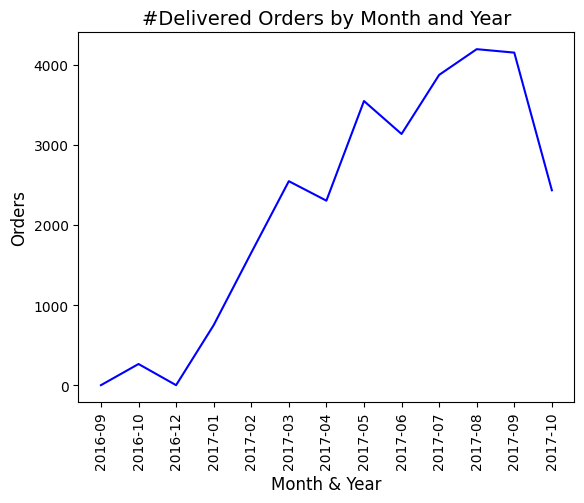

In [52]:
orders_delivered["order_purchase_timestamp"]
order_count = orders_delivered.groupby(orders_delivered["order_purchase_timestamp"].dt.to_period("M"))["order_id"].nunique()

plt.plot(order_count.index.astype(str), order_count.values, color="blue")

plt.title("#Delivered Orders by Month and Year", fontsize=14)
plt.xlabel("Month & Year", fontsize=12)
plt.ylabel("Orders", fontsize=12)

plt.xticks(rotation=90)
plt.show()

## Orders merge

In [53]:
# Carefully merge DataFrames
matching_table = orders.merge(reviews, on='order_id', how='left').merge(items, on='order_id', how='left')
matching_table

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11,2017-10-12 03:43:48,1.0,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,89b738e70a1ce346db29a20fb2910161,4.0,NaN,NaN,2017-07-27,2017-07-27 22:48:30,1.0,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36
2,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,e07549ef5311abcc92ba1784b093fb56,2.0,NaN,fiquei triste por n ter me atendido.,2017-05-13,2017-05-13 20:25:42,1.0,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,2017-04-19 13:25:17,49.90,16.05
3,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,07d67dd06ed5f88bef11ef6b464e79ae,5.0,NaN,NaN,2017-05-27,2017-05-28 02:59:57,1.0,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,59.99,15.17
4,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,fc4af8aea8ec3f1a3cd181d3d0cadbd5,1.0,NaN,NaN,2017-02-03,2017-02-05 01:58:35,1.0,ac1789e492dcd698c5c10b97a671243a,63b9ae557efed31d1f7687917d248a8d,2017-01-27 18:29:09,19.90,16.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34465,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07,ebd75732b5804e934123d11ec1f11db0,5.0,NaN,NaN,2017-10-21,2017-10-23 14:48:40,2.0,49d2e2460386273b195e7e59b43587c3,1caf283236cd69af44cbc09a0a1e7d32,2017-10-10 20:07:14,26.90,36.98
34466,aa04ef5214580b06b10e2a378300db44,f01a6bfcc730456317e4081fe0c9940e,delivered,2017-01-27 00:30:03,2017-01-27 01:05:25,2017-01-30 11:40:16,2017-02-07 13:15:25,2017-03-17,e8995c053d3db2d9c07407efe7de52dd,5.0,NaN,NaN,2017-02-08,2017-02-11 12:37:36,1.0,9fc063fd34fed29ccc57b7f8e8d03388,ccc4bbb5f32a6ab2b7066a4130f114e3,2017-02-03 00:30:03,370.00,19.43
34467,880675dff2150932f1601e1c07eadeeb,47cd45a6ac7b9fb16537df2ccffeb5ac,delivered,2017-02-23 09:05:12,2017-02-23 09:15:11,2017-03-01 10:22:52,2017-03-06 11:08:08,2017-03-22,96e8f371a3983122b739944537e15525,5.0,NaN,NaN,2017-03-07,2017-03-11 15:42:41,1.0,ea73128566d1b082e5101ce46f8107c7,391fc6631aebcf3004804e51b40bcf1e,2017-02-27 09:05:12,139.90,16.09
34468,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,e262b3f92d1ce917aa412a9406cf61a6,5.0,NaN,NaN,2017-03-22,2017-03-23 11:02:08,1.0,ac35486adb7b02598c182c2ff2e05254,e24fc9fcd865784fb25705606fe3dfe7,2017-03-15 09:54:05,72.00,13.08


In [54]:
matching_table = orders\
        .merge(customers, on='customer_id', how='inner')\
        .merge(reviews, on="order_id", how="inner")\
        .merge(items, on="order_id", how="inner")\
        .merge(sellers, on='seller_id', how='inner')
matching_table

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11,2017-10-12 03:43:48,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP
1,8736140c61ea584cb4250074756d8f3b,ab8844663ae049fda8baf15fc928f47f,delivered,2017-08-10 13:35:55,2017-08-10 13:50:09,2017-08-11 13:52:35,2017-08-16 19:03:36,2017-08-23,02c9e0c05a817d4562ec0e8c90f29dba,8577,itaquaquecetuba,SP,b8238c6515192f8129081e17dc57d169,5,NaN,"custo beneficio, simples de usar e rápido",2017-08-17,2017-08-21 12:43:27,1,b00a32a0b42fd65efb58a5822009f629,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-16 13:50:09,75.90,7.79,9350,maua,SP
2,a0151737f2f0c6c0a5fd69d45f66ceea,fc2697314ab7fbeda62bb6f1afa4efcd,delivered,2017-07-12 14:11:58,2017-07-12 14:30:18,2017-07-13 12:47:05,2017-07-18 16:24:42,2017-07-25,bdd30e6e39cc70dde8665187b57af402,13820,jaguariuna,SP,fa5bf792d42ed25f80c54d18aeaa83de,4,NaN,NaN,2017-07-19,2017-07-24 13:59:59,1,725cbfcaff95a4d43742fdf13cf43c75,3504c0cb71d7fa48d967e0e4c94d59d9,2017-07-18 14:30:18,44.99,7.78,9350,maua,SP
3,a3bf941183211246f0d42ad757cba127,3718e1873d5dc3e8d96c0ab783278b02,delivered,2017-07-24 22:16:25,2017-07-25 22:25:11,2017-07-26 14:57:42,2017-07-28 19:06:46,2017-08-04,1bcb517dc3cc80868d2fa941174f386c,6298,osasco,SP,5fe3f65882f521f0fbc41e59b9fbff24,4,NaN,NaN,2017-07-29,2017-08-01 20:06:40,1,725cbfcaff95a4d43742fdf13cf43c75,3504c0cb71d7fa48d967e0e4c94d59d9,2017-07-31 22:25:11,44.99,7.78,9350,maua,SP
4,1462290799412b71be32dd880eaf4e1b,220e4b027f0294fd79d2869ef67e7db6,delivered,2017-08-19 14:06:58,2017-08-22 04:10:55,2017-08-23 13:54:29,2017-08-29 19:35:06,2017-09-15,123ae28184c9e80638e71d40e37adc27,94130,gravatai,RS,36f6f70dc5e67e8e43b109cae0e92d40,4,NaN,É garantido e de confiança .,2017-08-30,2017-08-31 02:21:39,1,d7faab3fa0091d1220a8ada9cae1bab3,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-28 04:10:55,29.90,14.10,9350,maua,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33798,39e89b39b5cc8b5e3a38f23e915d1823,2b91bc260dcffbdacd12c4b09e5c7463,delivered,2017-07-24 11:29:43,2017-07-24 11:43:21,2017-07-24 22:34:38,2017-08-10 19:42:10,2017-08-23,bd0a735ae91504c00c71638c720e3cca,45051,vitoria da conquista,BA,e6de6c25dc2f6e602c1227e20756c992,5,NaN,NaN,2017-08-11,2017-08-16 14:34:55,1,24fcd474105d95d2002f38f0cacf87ee,72c73be2b085b9d57650dd53eb2004c9,2017-07-28 11:43:21,29.40,17.92,2116,sao paulo,SP
33799,fbff77db5421bb7e1da292db45d07e75,7795e3faa6e16fc40aafee568b25a85d,delivered,2017-03-15 11:41:46,2017-03-15 11:41:46,2017-03-16 04:19:03,2017-03-20 10:34:54,2017-04-03,6ee4fdb7edab032aaa8392bab5446546,9060,santo andre,SP,c13d0d31c88734e32cd3067bf14d34d7,5,NaN,NaN,2017-03-21,2017-03-23 00:59:49,1,654ccc4e5459e7ba6b8d9fb04c45b9db,2d8cfba3fcd3170555941605edaa196a,2017-03-21 11:41:46,45.00,10.96,6080,osasco,SP
33800,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaT,NaT,2017-03-30,78a159045124eb7601951b917a42034f,89111,gaspar,SC,c950324a42c5796d06f569f77d8b2e88,1,NaN,NaN,2017-04-01,2017-04-01 10:24:03,1,241a1ffc9cf969b27de6e72301020268,85

In [55]:
# test get matching table
matching_table_import = Olist().get_matching_table()
matching_table_import

,customer_id,order_id,customer_unique_id,review_id,product_id,seller_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,a54f0611adc9ed256b57ede6b6eb5114,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9
1,b0830fb4747a6c6d20dea0b8c802d7ef,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,8d5266042046a06655c8db133d120ba5,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962
2,41ce2a54c0b03bf3443c3d931a367089,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,e73b67b67587f7644d5bd1a52deb1b01,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2
3,f88197465ea7920adcdbec7375364d82,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,359d03e676b3c069f62cadba8dd3f6e8,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106
4,8ab97904e6daea8866dbdbc4fb7aad2c,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,e50934924e227544ba8246aeb3770dd4,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8
...,...,...,...,...,...,...
114087,1fca14ff2861355f6e5f14306ff977a7,63943bddc261676b46f01ca7ac2f7bd8,da62f9e57a76d978d02ab5362c509660,29bb71b2760d0f876dfa178a76bc4734,f1d4ce8c6dd66c47bbaa8c6781c2a923,1f9ab4708f3056ede07124aad39a2554
114088,1aa71eb042121263aafbe80c1b562c9c,83c1379a015df1e13d02aae0204711ab,737520a9aad80b3fbbdad19b66b37b30,371579771219f6db2d830d50805977bb,b80910977a37536adeddd63663f916ad,d50d79cb34e38265a8649c383dcffd48
114089,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,8ab6855b9fe9b812cd03a480a25058a1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48
114090,b331b74b18dc79bcdf6532d51e1637c1,11c177c8e97725db2631073c19f07b62,5097a5312c8b157bb7be58ae360ef43c,8ab6855b9fe9b812cd03a480a25058a1,d1c427060a0f73f6b889a5c7c61f2ac4,a1043bafd471dff536d0c462352beb48


In [56]:
# Inspect the cardinality and `nunique` of the final DataFrame. It should match (114100, 5)
print(matching_table.shape)
print('unique values: ')
print(matching_table.nunique())

(33803, 27)
unique values: 
order_id                         29491
customer_id                      29491
order_status                         7
order_purchase_timestamp         29351
order_approved_at                28742
order_delivered_carrier_date     26667
order_delivered_customer_date    28309
order_estimated_delivery_date      242
customer_unique_id               28626
customer_zip_code_prefix         10425
customer_city                     2859
customer_state                      27
review_id                        29389
review_score                         5
review_comment_title                 4
review_comment_message           11315
review_creation_date               356
review_answer_timestamp          29357
order_item_id                       21
product_id                       12402
seller_id                         1469
shipping_limit_date              28958
price                             2927
freight_value                     4028
seller_zip_code_prefix            12

In [57]:
matching_table['order_id'].duplicated().sum()

4312

In [58]:
matching_table.loc[matching_table['order_id'].duplicated()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state
49,9d513821c0477231fc7c1bfd684d13d8,00a6e2753fc2652cb87386ffbf5792b2,delivered,2017-02-20 21:31:59,2017-02-22 06:50:09,2017-02-23 07:23:34,2017-03-21 10:35:41,2017-03-17,3abdf4f27efce96f8573a88343a4084e,4944,sao paulo,SP,230eae5559b410b3a71bb91b587f9bb2,5,NaN,NaN,2017-03-22,2017-03-22 23:22:10,2,fd424396761d9e1609c5516b7d8ce17b,8581055ce74af1daba164fdbd55a40de,2017-02-24 21:31:59,80.4,15.67,7112,guarulhos,SP
64,aff8085aa67afd7180c91552d939a4dd,aac4712a1869e7e6c81ad015c0f098aa,delivered,2017-05-29 13:06:03,2017-05-30 04:30:30,2017-05-31 09:07:44,2017-06-13 11:53:57,2017-06-27,be2931e7e0cff6a086cc7a0a04bb0816,76510,crixas,GO,e2d1947e82d9ed397e5b0d3d70631c81,1,NaN,Comprei dois pneus ( dianteiro e traseiro ) mas so recebi o traseiro.,2017-06-14,2017-06-15 03:10:41,2,29e4631be78811ab993ae12613053b53,8581055ce74af1daba164fdbd55a40de,2017-06-05 04:30:30,138.0,18.48,7112,guarulhos,SP
78,d81dff089ae648dacea746f77643f86e,5e6c17c1aac5a1acf6e38746eeebc11d,delivered,2017-01-24 22:16:05,2017-01-24 22:25:33,2017-01-26 10:19:05,2017-02-01 00:47:45,2017-02-17,2fb4183605995aad1ff94ef572b91a21,13067,campinas,SP,58fd5e8968a445280ff157b85f694d44,5,NaN,NaN,2017-02-02,2017-02-02 18:30:05,2,0c9ff9d8ed9b9bdd825487b3a66e05f5,8581055ce74af1daba164fdbd55a40de,2017-01-28 22:16:05,238.9,23.20,7112,guarulhos,SP
79,d81dff089ae648dacea746f77643f86e,5e6c17c1aac5a1acf6e38746eeebc11d,delivered,2017-01-24 22:16:05,2017-01-24 22:25:33,2017-01-26 10:19:05,2017-02-01 00:47:45,2017-02-17,2fb4183605995aad1ff94ef572b91a21,13067,campinas,SP,58fd5e8968a445280ff157b85f694d44,5,NaN,NaN,2017-02-02,2017-02-02 18:30:05,3,0c9ff9d8ed9b9bdd825487b3a66e05f5,8581055ce74af1daba164fdbd55a40de,2017-01-28 22:16:05,238.9,23.20,7112,guarulhos,SP
80,d81dff089ae648dacea746f77643f86e,5e6c17c1aac5a1acf6e38746eeebc11d,delivered,2017-01-24 22:16:05,2017-01-24 22:25:33,2017-01-26 10:19:05,2017-02-01 00:47:45,2017-02-17,2fb4183605995aad1ff94ef572b91a21,13067,campinas,SP,58fd5e8968a445280ff157b85f694d44,5,NaN,NaN,2017-02-02,2017-02-02 18:30:05,4,1d3f55c00acdb29bd959f2760abc8b7d,8581055ce74af1daba164fdbd55a40de,2017-01-28 22:16:05,176.9,16.30,7112,guarulhos,SP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33789,26c2b0e7dd3eb988721bb042f783c80e,a02334ababbac97e012344f330e4fbb0,delivered,2017-08-02 08:58:27,2017-08-04 11:33:49,2017-08-02 20:33:04,2017-08-10 18:16:37,2017-08-28,dfe96ce580a21f177c1d85fe2c78e1ab,21555,rio de janeiro,RJ,caaac848110409f69b7b90c5a4cc4c94,4,NaN,NaN,2017-08-11,2017-08-15 09:07:19,3,de7087431dce1f95bf39105df32825cd,262237171f48e85819065498cac80d7b,2017-08-08 09:15:10,59.9,17.99,88352,brusque,SC
33790,26c2b0e7dd3eb988721bb042f783c80e,a02334ababbac97e012344f330e4fbb0,delivered,2017-08-02 08:58:27,2017-08-04 11:33:49,2017-08-02 20:33:04,2017-08-10 18:16:37,2017-08-28,dfe96ce580a21f177c1d85fe2c78e1ab,21555,rio de janeiro,RJ,caaac848110409f69b7b90c5a4cc4c94,4,NaN,NaN,2017-08-11,2017-08-15 09:07:19,4,de7087431dce1f95bf39105df32825cd,262237171f48e85819065498cac80d7b,2017-08-08 09:15:10,59.9,17.99,88352,brusque,SC
33791,26c2b0e7dd3eb988721bb042f783c80e,a02334ababbac97e012344f330e4fbb0,delivered,2017-08-02 08:58:27,2017-08-04 11:33:49,2017-08-02 20:33:04,2017-08-10 18:16:37,2017-08-28,dfe96ce580a21f177c1d85fe2c78e1ab,21555,rio de janeiro,RJ,caaac848110409f69b7b90c5a4cc4c94,4,NaN,NaN,2017-08-11,2017-08-15 09:07:19,5,de7087431dce1f95bf39105df32825cd,262237171f48e85819065498cac80d7b,2017-08-08 09:15:10,59.9,17.99,88352,brusque,SC
33797,d3a84031db6c5de813d

In [59]:
matching_table.loc[matching_table['order_id'] == 'acce194856392f074dbf9dada14d8d82']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state


In [60]:
products[products.product_id.isin(['977f9f63dd360c2a32ece2f93ad6d306', '977f9f63dd360c2a32ece2f93ad6d306'])]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [61]:
# check n# orders per customer

In [62]:
#orders = data['orders'][['customer_id', 'order_id']]
#customers = data['customers'][['customer_id', 'customer_unique_id']]

In [63]:
match_orders = orders.merge(customers, on='customer_id', how='left')

In [64]:
match_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR
2,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS
3,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ
4,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,39382392765b6dc74812866ee5ee92a7,99655,faxinalzinho,RS
...,...,...,...,...,...,...,...,...,...,...,...,...
30091,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07,c716cf2b5b86fb24257cffe9e7969df8,78048,cuiaba,MT
30092,aa04ef5214580b06b10e2a378300db44,f01a6bfcc730456317e4081fe0c9940e,delivered,2017-01-27 00:30:03,2017-01-27 01:05:25,2017-01-30 11:40:16,2017-02-07 13:15:25,2017-03-17,e03dbdf5e56c96b106d8115ac336f47f,35502,divinopolis,MG
30093,880675dff2150932f1601e1c07eadeeb,47cd45a6ac7b9fb16537df2ccffeb5ac,delivered,2017-02-23 09:05:12,2017-02-23 09:15:11,2017-03-01 10:22:52,2017-03-06 11:08:08,2017-03-22,831ce3f1bacbd424fc4e38fbd4d66d29,5127,sao paulo,SP
30094,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP


In [65]:
orders_count = match_orders \
                .groupby('customer_unique_id')['order_id'] \
                .nunique().reset_index(name='orders_count')

In [66]:
orders_count['count_category'] = np.where(orders_count['orders_count'] == 1, '1', '2+')

In [67]:
orders_count.sort_values(by='orders_count', ascending=False)

,customer_unique_id,orders_count,count_category
16141,8d50f5eadf50201ccdcedfb9e2ac8455,7,2+
2262,12f5d6e1cbf93dafd9dcc19095df0b3d,6,2+
11481,63cfc61cee11cbe306bff5857d00bfe4,4,2+
27471,f0e310a6839dce9de1638e0fe5ab282a,4,2+
8274,47c1a3033b8b77b3ab6e109eb4d5fdf3,4,2+
...,...,...,...
9844,55481ae32ead3c8c734d8acee5ccf3a2,1,1
9843,554692dcba8b169a3e0ec2ef1c8bd473,1,1
9842,55442d4546e0a75dc8c38e90be43565c,1,1
9841,553e08d19f15562d267d0e551cbab2d0,1,1


In [68]:
orders_info = pd.concat([orders_count['orders_count'].value_counts(normalize=True),
                        orders_count['orders_count'].value_counts()], 
                        axis=1,
                        keys=('percent','count customers'))
orders_info.index.name = 'orders per customer'
orders_info

,percent,count customers
orders per customer,,
1,0.972399,28396
2,0.025170,735
3,0.002020,59
4,0.000342,10
6,0.000034,1
7,0.000034,1


In [69]:
orders_info_cum = pd.concat([orders_count['count_category'].value_counts(normalize=True),
                        orders_count['count_category'].value_counts()], 
                        axis=1,
                        keys=('perc','count'))
orders_info_cum.index.name = 'orders per customer'
orders_info_cum

,perc,count
orders per customer,,
1,0.972399,28396
2+,0.027601,806


=> ~3.12 % of the total of customers (2997 total) has made more than 1 order.

In [70]:
## selecting / merging data for clustering


In [71]:
match_orders = match_orders.merge(orders_count, on='customer_unique_id', how='left')

In [72]:
match_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,orders_count,count_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,2,2+
1,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,80bb27c7c16e8f973207a5086ab329e2,86320,congonhinhas,PR,1,1
2,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,36edbb3fb164b1f16485364b6fb04c73,98900,santa rosa,RS,1,1
3,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,932afa1e708222e5821dac9cd5db4cae,26525,nilopolis,RJ,1,1
4,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,39382392765b6dc74812866ee5ee92a7,99655,faxinalzinho,RS,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30091,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07,c716cf2b5b86fb24257cffe9e7969df8,78048,cuiaba,MT,1,1
30092,aa04ef5214580b06b10e2a378300db44,f01a6bfcc730456317e4081fe0c9940e,delivered,2017-01-27 00:30:03,2017-01-27 01:05:25,2017-01-30 11:40:16,2017-02-07 13:15:25,2017-03-17,e03dbdf5e56c96b106d8115ac336f47f,35502,divinopolis,MG,1,1
30093,880675dff2150932f1601e1c07eadeeb,47cd45a6ac7b9fb16537df2ccffeb5ac,delivered,2017-02-23 09:05:12,2017-02-23 09:15:11,2017-03-01 10:22:52,2017-03-06 11:08:08,2017-03-22,831ce3f1bacbd424fc4e38fbd4d66d29,5127,sao paulo,SP,1,1
30094,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,6359f309b166b0196dbf7ad2ac62bb5a,12209,sao jose dos campos,SP,1,1


In [73]:
## picking orders from customers_unique_id having made more than 2 orders 
match_orders_2p = match_orders[['customer_id','order_id', 'customer_unique_id']].loc[match_orders['orders_count'] > 1]
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
14,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
17,911e4c37f5cafe1604fe6767034bf1ae,a685d016c8a26f71a0bb67821070e398,51838d41add414a0b1b989b7d251d9ee
24,f26a435864aebedff7f7c84f82ee229f,b8801cccd8068de30112e4f49903d74a,bb4d84a2b45b22ed710ac8c0dec63d1a
30,8628fac2267e8c8804525da99c10ed0e,d3d6788577c9592da441752e8a1dd5e3,7973a6ba9c81ecaeb3d628c33c7c7c48
...,...,...,...
29974,cad8cb02b68f53c2db4a122ca3aee6dc,b4d1dd77cf2c5fe4f153c568189a1e39,b530945168f12f82a3f9be3a5e243afa
29975,e16cf97d3d5183b6516d4fa8a476285c,3003eed153ba33c08d9352250d65ba75,335be0ca4b7aa8578e364a76efd4da52
29979,3dc99b2fcf41c0898cfc7f38c2fefe5e,76de574e14e58baded25a12dce8075c1,970e5961383615662043afa2d9c68802
30037,275f5f7ae20f7e971f370b0c19728efb,634de1499ffe996612a8960e10d1c4ee,7a6b4947e01039432cac229435d058ee


In [74]:
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
14,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
17,911e4c37f5cafe1604fe6767034bf1ae,a685d016c8a26f71a0bb67821070e398,51838d41add414a0b1b989b7d251d9ee
24,f26a435864aebedff7f7c84f82ee229f,b8801cccd8068de30112e4f49903d74a,bb4d84a2b45b22ed710ac8c0dec63d1a
30,8628fac2267e8c8804525da99c10ed0e,d3d6788577c9592da441752e8a1dd5e3,7973a6ba9c81ecaeb3d628c33c7c7c48
...,...,...,...
29974,cad8cb02b68f53c2db4a122ca3aee6dc,b4d1dd77cf2c5fe4f153c568189a1e39,b530945168f12f82a3f9be3a5e243afa
29975,e16cf97d3d5183b6516d4fa8a476285c,3003eed153ba33c08d9352250d65ba75,335be0ca4b7aa8578e364a76efd4da52
29979,3dc99b2fcf41c0898cfc7f38c2fefe5e,76de574e14e58baded25a12dce8075c1,970e5961383615662043afa2d9c68802
30037,275f5f7ae20f7e971f370b0c19728efb,634de1499ffe996612a8960e10d1c4ee,7a6b4947e01039432cac229435d058ee


In [75]:
##  adding orders categories and reviews info

In [76]:
reviews

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super recomendo essa loja!",2018-03-22,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01,2018-07-02 12:59:13


In [77]:
match_orders_2p

,customer_id,order_id,customer_unique_id
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff
14,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514
17,911e4c37f5cafe1604fe6767034bf1ae,a685d016c8a26f71a0bb67821070e398,51838d41add414a0b1b989b7d251d9ee
24,f26a435864aebedff7f7c84f82ee229f,b8801cccd8068de30112e4f49903d74a,bb4d84a2b45b22ed710ac8c0dec63d1a
30,8628fac2267e8c8804525da99c10ed0e,d3d6788577c9592da441752e8a1dd5e3,7973a6ba9c81ecaeb3d628c33c7c7c48
...,...,...,...
29974,cad8cb02b68f53c2db4a122ca3aee6dc,b4d1dd77cf2c5fe4f153c568189a1e39,b530945168f12f82a3f9be3a5e243afa
29975,e16cf97d3d5183b6516d4fa8a476285c,3003eed153ba33c08d9352250d65ba75,335be0ca4b7aa8578e364a76efd4da52
29979,3dc99b2fcf41c0898cfc7f38c2fefe5e,76de574e14e58baded25a12dce8075c1,970e5961383615662043afa2d9c68802
30037,275f5f7ae20f7e971f370b0c19728efb,634de1499ffe996612a8960e10d1c4ee,7a6b4947e01039432cac229435d058ee


In [78]:
products = products.merge(product_names, on='product_category_name', how='left')
products = products.reindex(['product_id', 'product_category_name',  'product_category_name_english', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm'], axis=1)
products

,product_id,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,furniture_decor,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,construction_tools_lights,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,bed_bath_table,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,computers_accessories,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [79]:
m_df = match_orders_2p \
    .merge(items[['order_id', 'product_id', 'price']], on='order_id', how='left') \
    .merge(products[['product_id', 'product_category_name_english']], on='product_id', how='left') \
    .merge(reviews, on='order_id', how='left')

In [80]:
m_df

,customer_id,order_id,customer_unique_id,product_id,price,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,9ef432eb6251297304e76186b10a928d,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,29.99,housewares,a54f0611adc9ed256b57ede6b6eb5114,4.0,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11,2017-10-12 03:43:48
1,569cf68214806a39acc0f39344aea67f,d17dc4a904426827ca80f2ccb3a6be56,c2551ea089b7ebbc67a2ea8757152514,ba4bfbf74dbe7ab37e263b9326da0523,36.90,sports_leisure,bcab37e37778893d858b3d159849a56d,4.0,NaN,NaN,2017-05-26,2017-06-01 19:10:49
2,911e4c37f5cafe1604fe6767034bf1ae,a685d016c8a26f71a0bb67821070e398,51838d41add414a0b1b989b7d251d9ee,ebd7c847c1e1cb69ec374ae0ebee1f4c,84.90,furniture_decor,19d60869413aa63834affc9ecc9d9f90,1.0,NaN,Não recebi,2017-04-02,2017-04-02 10:58:38
3,f26a435864aebedff7f7c84f82ee229f,b8801cccd8068de30112e4f49903d74a,bb4d84a2b45b22ed710ac8c0dec63d1a,154e7e31ebfa092203795c972e5804a6,19.99,health_beauty,2aff17b27e1fa4125d6d9e9800b22d07,3.0,NaN,Tudo em ordem.,2017-08-02,2017-08-02 20:06:46
4,8628fac2267e8c8804525da99c10ed0e,d3d6788577c9592da441752e8a1dd5e3,7973a6ba9c81ecaeb3d628c33c7c7c48,7c1bd920dbdf22470b68bde975dd3ccf,58.99,health_beauty,8f5b66ebafa5c69767c42dfeacfb4c86,5.0,NaN,NaN,2017-10-11,2017-10-15 20:47:19
...,...,...,...,...,...,...,...,...,...,...,...,...
2273,e16cf97d3d5183b6516d4fa8a476285c,3003eed153ba33c08d9352250d65ba75,335be0ca4b7aa8578e364a76efd4da52,1846ec5a92ed15d0dbf9e0e86c29085c,155.00,home_appliances,3a3c8a7cefc90bf9b10ac53451f4549e,1.0,NaN,"O produto que eu comprei veio errado, comprei duas placas de lavadora diferentes, veio duas iguais veio duas bwg/C10A, e necessito da outra placa Bwl09 urgente",2017-07-04,2017-07-05 09:46:50
2274,3dc99b2fcf41c0898cfc7f38c2fefe5e,76de574e14e58baded25a12dce8075c1,970e5961383615662043afa2d9c68802,4a9389b1a1ad7d52963f24ce0391a08f,89.00,sports_leisure,9b0e89862fcb8419c30f3f290e770db1,5.0,NaN,Amo esse baratheon....,2017-06-23,2017-07-01 11:42:49
2275,3dc99b2fcf41c0898cfc7f38c2fefe5e,76de574e14e58baded25a12dce8075c1,970e5961383615662043afa2d9c68802,4a9389b1a1ad7d52963f24ce0391a08f,89.00,sports_leisure,0234abe22674d1798d6c3f95aea9033b,5.0,NaN,Bom demias!!! adoro o baratheon.,2017-06-25,2017-07-01 11:39:23
2276,275f5f7ae20f7e971f370b0c19728efb,634de1499ffe996612a8960e10d1c4ee,7a6b4947e01039432cac229435d058ee,fcdb929c70287379ce31deed3f733d72,209.90,bed_bath_table,502262530835f86e1ecb3a378e2cfe1f,3.0,NaN,"Produto chegou, mas tinha pouca especificação, nao vai me atender, preciso devolver",2017-09-26,2017-09-27 10:06:37


In [81]:
# more rows => more items/products total than orders total (i.e. orders with multiple items)
# check out orders with multiple items to be sure it will be usable / absence of duplicates (in price for ex)

In [82]:
product_count = m_df \
                .groupby('order_id')['product_id'] \
                .nunique().reset_index(name='prod_count')
product_count.sort_values(by='prod_count', ascending=False)

,order_id,prod_count
589,5a3b1c29a49756e75f1ef513383c0c12,6
1419,d731191f76c39fe5c7d22edddb6836ba,4
840,7e3fefb35b0b1d765a343618ca5d454c,4
1283,c27cd942c2a926d25153090afa106ceb,4
1357,cc2999bc678cab0949b90c4759d7a284,4
...,...,...
821,7a9d4c7f9b068337875b95465330f2fc,0
587,5a14c8b3d919a4ef3f3428b0459c47b2,0
934,8cacf6d8c088e18ca96ee6d5a138461b,0
1387,d177b7c08ed2934d5888e7fd236d42e1,0


In [83]:
product_info = pd.concat([product_count['prod_count'].value_counts(normalize=True),
                        product_count['prod_count'].value_counts()], 
                        axis=1,
                        keys=('percent','count orders'))
product_info.index.name = 'products per order'
product_info

,percent,count orders
products per order,,
1,0.924706,1572
2,0.051765,88
0,0.012353,21
3,0.008235,14
4,0.002353,4
6,0.000588,1


In [84]:
# checking order 5a3b1c29a49756e75f1ef513383c0c12

#m_df.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']

# handles duplicates from matching_table (reviews...)
m_df[['product_id', 'price', 'product_category_name_english']]\
.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']\
.drop_duplicates()

,product_id,price,product_category_name_english
364,99444c1e11fc38755dae86f5c67d3d1a,49.99,bed_bath_table
366,17d8b8e9c21ec0fc5b33724e32fe422e,58.90,bed_bath_table
368,399f54c06661d06ca45c6e24ed238e0e,61.90,bed_bath_table
370,6a0713a63e990052795623e76cc2995e,72.90,bed_bath_table
376,d25bbb182b51d1594fe3b54a27ae143e,69.90,bed_bath_table
378,e95fb3a80ca294f39de925b6428f3a32,78.90,bed_bath_table


In [85]:
# check products
check_prod = m_df.loc[m_df['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']['product_id']
products.loc[products['product_id'].isin(check_prod)]

,product_id,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
5347,d25bbb182b51d1594fe3b54a27ae143e,cama_mesa_banho,bed_bath_table,34.0,308.0,1.0,1900.0,58.0,15.0,46.0
14912,6a0713a63e990052795623e76cc2995e,cama_mesa_banho,bed_bath_table,31.0,151.0,1.0,900.0,40.0,4.0,30.0
20180,17d8b8e9c21ec0fc5b33724e32fe422e,cama_mesa_banho,bed_bath_table,26.0,212.0,2.0,1000.0,30.0,4.0,40.0
25905,e95fb3a80ca294f39de925b6428f3a32,cama_mesa_banho,bed_bath_table,29.0,263.0,1.0,1300.0,33.0,9.0,38.0
29768,99444c1e11fc38755dae86f5c67d3d1a,cama_mesa_banho,bed_bath_table,40.0,162.0,1.0,900.0,33.0,9.0,38.0
30087,399f54c06661d06ca45c6e24ed238e0e,cama_mesa_banho,bed_bath_table,34.0,216.0,2.0,1100.0,33.0,9.0,38.0


In [86]:
items.loc[items['order_id'] == '5a3b1c29a49756e75f1ef513383c0c12']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
39679,5a3b1c29a49756e75f1ef513383c0c12,1,99444c1e11fc38755dae86f5c67d3d1a,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,49.99,7.10
39680,5a3b1c29a49756e75f1ef513383c0c12,2,17d8b8e9c21ec0fc5b33724e32fe422e,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,58.90,2.66
39681,5a3b1c29a49756e75f1ef513383c0c12,3,399f54c06661d06ca45c6e24ed238e0e,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,61.90,11.98
39682,5a3b1c29a49756e75f1ef513383c0c12,4,6a0713a63e990052795623e76cc2995e,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,72.90,2.66
39683,5a3b1c29a49756e75f1ef513383c0c12,5,99444c1e11fc38755dae86f5c67d3d1a,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,49.99,7.10
39684,5a3b1c29a49756e75f1ef513383c0c12,6,399f54c06661d06ca45c6e24ed238e0e,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,61.90,11.98
39685,5a3b1c29a49756e75f1ef513383c0c12,7,d25bbb182b51d1594fe3b54a27ae143e,cfb1a033743668a192316f3c6d1d2671,2017-10-24 13:06:21,69.90,33.72
39686,5a3b1c29a49756e75f1ef513383c0c12,8,e95fb3a80ca294f39de925b6428f3a32,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,78.90,7.98
39687,5a3b1c29a49756e75f1ef513383c0c12,9,e95fb3a80ca294f39de925b6428f3a32,d2374cbcbb3ca4ab1086534108cc3ab7,2017-10-24 13:06:21,78.90,7.98
39688,5a3b1c29a49756e75f1ef513383c0c12,10,d25bbb182b51d1594fe3b54a27ae143e,cfb1a033743668a192316f3c6d1d2671,2017-10-24 13:06:21,69.90,33.72


In [87]:
# checking order e43f88863d1cc9cff18d753d439d42e8
m_df.loc[m_df['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']

,customer_id,order_id,customer_unique_id,product_id,price,product_category_name_english,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp


In [88]:
# check products
check_prod = m_df.loc[m_df['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']['product_id']
products.loc[products['product_id'].isin(check_prod)]

,product_id,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm


In [89]:
items.loc[items['order_id'] == 'e43f88863d1cc9cff18d753d439d42e8']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
100670,e43f88863d1cc9cff18d753d439d42e8,1,9036be77e0a74cca6eeef0740649b97b,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100671,e43f88863d1cc9cff18d753d439d42e8,2,238314b88e4b8ffa496db6b1a201d897,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100672,e43f88863d1cc9cff18d753d439d42e8,3,28447390cfd2a411fcb8c008b6163da2,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100673,e43f88863d1cc9cff18d753d439d42e8,4,2e0b9273624db778d82fd3b18becec24,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100674,e43f88863d1cc9cff18d753d439d42e8,5,8fa5bb1e4de7a63ee554487c2f2ee076,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25
100675,e43f88863d1cc9cff18d753d439d42e8,6,b65214d387c754bb0f858a4a5a0f41ad,de23c3b98a88888289c6f5cc1209054a,2017-12-11 14:30:51,69.99,16.25


In [90]:
items.duplicated().sum()

0

In [91]:
# => may have to handle the "duplicate" prices not matching reality (price of the whole order for singular products)

## RFM : Recency / Frequency / Monetary values

### Préparation

In [92]:
data['orders']

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06
...,...,...,...,...,...,...,...,...
99433,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07
99434,aa04ef5214580b06b10e2a378300db44,f01a6bfcc730456317e4081fe0c9940e,delivered,2017-01-27 00:30:03,2017-01-27 01:05:25,2017-01-30 11:40:16,2017-02-07 13:15:25,2017-03-17
99435,880675dff2150932f1601e1c07eadeeb,47cd45a6ac7b9fb16537df2ccffeb5ac,delivered,2017-02-23 09:05:12,2017-02-23 09:15:11,2017-03-01 10:22:52,2017-03-06 11:08:08,2017-03-22
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28


In [93]:
ord_time = data['orders'][['order_id','customer_id', 'order_purchase_timestamp']]
ord_time = ord_time.merge(customers, on='customer_id', how='left')\
[['customer_unique_id', 'order_id', 'order_purchase_timestamp']]
ord_time

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33
1,80bb27c7c16e8f973207a5086ab329e2,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09 21:57:05
2,36edbb3fb164b1f16485364b6fb04c73,136cce7faa42fdb2cefd53fdc79a6098,2017-04-11 12:22:08
3,932afa1e708222e5821dac9cd5db4cae,6514b8ad8028c9f2cc2374ded245783f,2017-05-16 13:10:30
4,39382392765b6dc74812866ee5ee92a7,76c6e866289321a7c93b82b54852dc33,2017-01-23 18:29:09
...,...,...,...
30091,c716cf2b5b86fb24257cffe9e7969df8,9115830be804184b91f5c00f6f49f92d,2017-10-04 19:57:37
30092,e03dbdf5e56c96b106d8115ac336f47f,aa04ef5214580b06b10e2a378300db44,2017-01-27 00:30:03
30093,831ce3f1bacbd424fc4e38fbd4d66d29,880675dff2150932f1601e1c07eadeeb,2017-02-23 09:05:12
30094,6359f309b166b0196dbf7ad2ac62bb5a,9c5dedf39a927c1b2549525ed64a053c,2017-03-09 09:54:05


In [94]:
ord_time['order_purchase_timestamp'] = pd.to_datetime(ord_time['order_purchase_timestamp']).dt.date

In [95]:
ord_time['order_purchase_timestamp'].isnull().values.any()

False

In [96]:
ord_time

,customer_unique_id,order_id,order_purchase_timestamp
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02
1,80bb27c7c16e8f973207a5086ab329e2,a4591c265e18cb1dcee52889e2d8acc3,2017-07-09
2,36edbb3fb164b1f16485364b6fb04c73,136cce7faa42fdb2cefd53fdc79a6098,2017-04-11
3,932afa1e708222e5821dac9cd5db4cae,6514b8ad8028c9f2cc2374ded245783f,2017-05-16
4,39382392765b6dc74812866ee5ee92a7,76c6e866289321a7c93b82b54852dc33,2017-01-23
...,...,...,...
30091,c716cf2b5b86fb24257cffe9e7969df8,9115830be804184b91f5c00f6f49f92d,2017-10-04
30092,e03dbdf5e56c96b106d8115ac336f47f,aa04ef5214580b06b10e2a378300db44,2017-01-27
30093,831ce3f1bacbd424fc4e38fbd4d66d29,880675dff2150932f1601e1c07eadeeb,2017-02-23
30094,6359f309b166b0196dbf7ad2ac62bb5a,9c5dedf39a927c1b2549525ed64a053c,2017-03-09


In [97]:
ord_time.dtypes

customer_unique_id          object
order_id                    object
order_purchase_timestamp    object
dtype: object

In [98]:
orders_price = items.groupby(['order_id']).agg('sum')
orders_price.head()

,order_item_id,price,freight_value
order_id,,,
00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29
00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93
000229ec398224ef6ca0657da4fc703e,1,199.00,17.87
00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79
00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14


In [99]:
# rename / reorganize dataset
ord_df = ord_time.merge(orders_price, on='order_id', how='outer')
ord_df.rename({'price':'total_revenue', 'order_purchase_timestamp': 'purchase_date'}, axis='columns', inplace=True)
ord_df = ord_df[['order_id', 'customer_unique_id', 'total_revenue', 'freight_value', 'purchase_date']]
ord_df

,order_id,customer_unique_id,total_revenue,freight_value,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,2017-10-02
1,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,147.90,27.36,2017-07-09
2,136cce7faa42fdb2cefd53fdc79a6098,36edbb3fb164b1f16485364b6fb04c73,49.90,16.05,2017-04-11
3,6514b8ad8028c9f2cc2374ded245783f,932afa1e708222e5821dac9cd5db4cae,59.99,15.17,2017-05-16
4,76c6e866289321a7c93b82b54852dc33,39382392765b6dc74812866ee5ee92a7,19.90,16.05,2017-01-23
...,...,...,...,...,...
99025,fffbee3b5462987e66fb49b1c5411df2,NaN,119.85,20.03,NaN
99026,fffc94f6ce00a00581880bf54a75a037,NaN,299.99,43.41,NaN
99027,fffcd46ef2263f404302a634eb57f7eb,NaN,350.00,36.53,NaN
99028,fffce4705a9662cd70adb13d4a31832d,NaN,99.90,16.95,NaN


In [100]:
orders_df_match = matching_table[['customer_unique_id', 'order_id','product_id', 'price', 'freight_value']].drop_duplicates()
orders_df_match

,customer_unique_id,order_id,product_id,price,freight_value
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,29.99,8.72
1,02c9e0c05a817d4562ec0e8c90f29dba,8736140c61ea584cb4250074756d8f3b,b00a32a0b42fd65efb58a5822009f629,75.90,7.79
2,bdd30e6e39cc70dde8665187b57af402,a0151737f2f0c6c0a5fd69d45f66ceea,725cbfcaff95a4d43742fdf13cf43c75,44.99,7.78
3,1bcb517dc3cc80868d2fa941174f386c,a3bf941183211246f0d42ad757cba127,725cbfcaff95a4d43742fdf13cf43c75,44.99,7.78
4,123ae28184c9e80638e71d40e37adc27,1462290799412b71be32dd880eaf4e1b,d7faab3fa0091d1220a8ada9cae1bab3,29.90,14.10
...,...,...,...,...,...
33797,ffb973f2bb1c0cb807a99341a9b20dcd,d3a84031db6c5de813d5a3a3489712ca,8ed9e6b1cbb80b223b70376a8659bee0,47.40,12.41
33798,bd0a735ae91504c00c71638c720e3cca,39e89b39b5cc8b5e3a38f23e915d1823,24fcd474105d95d2002f38f0cacf87ee,29.40,17.92
33799,6ee4fdb7edab032aaa8392bab5446546,fbff77db5421bb7e1da292db45d07e75,654ccc4e5459e7ba6b8d9fb04c45b9db,45.00,10.96
33800,78a159045124eb7601951b917a42034f,b159d0ce7cd881052da94fa165617b05,241a1ffc9cf969b27de6e72301020268,19.70,10.96


In [101]:
# Recency

=> To define 'Recency' we have to take into account the limit of the current dataframe, more than a min/max date, a simple analysis/display of the distribution of orders over dates would help (can cover some errors/outliers to get the general picture).

In [102]:
# check min / max dates and overall dates distribution of orders
# convert timestamp to date

In [103]:
ord_df.dtypes

order_id               object
customer_unique_id     object
total_revenue         float64
freight_value         float64
purchase_date          object
dtype: object

In [104]:
# https://practicaldatascience.co.uk/data-science/how-to-assign-rfm-scores-with-quantile-based-discretization
# => Recency is a measure of the number of days since the customer last placed an order. 

### Consolidation Dataframe RFM

In [105]:
df_customers = pd.DataFrame(ord_df['customer_unique_id'].unique())
df_customers.columns = ['customer_unique_id']
df_customers.head()

,customer_unique_id
0,7c396fd4830fd04220f754e42b4e5bff
1,80bb27c7c16e8f973207a5086ab329e2
2,36edbb3fb164b1f16485364b6fb04c73
3,932afa1e708222e5821dac9cd5db4cae
4,39382392765b6dc74812866ee5ee92a7


In [106]:
df_recency = ord_df.groupby('customer_unique_id')['purchase_date'].max().reset_index()
df_recency.columns = ['customer_unique_id'
                      ,'recency_date'
                     ]
df_customers = df_customers.merge(df_recency, on='customer_unique_id')
df_customers['recency'] = round((pd.to_datetime(f'{limit_date_strf}') - pd.to_datetime(df_customers['recency_date']))\
                                / np.timedelta64(1, 'D') ).astype(int)

In [107]:
df_customers

,customer_unique_id,recency_date,recency
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,15
1,80bb27c7c16e8f973207a5086ab329e2,2017-07-09,100
2,36edbb3fb164b1f16485364b6fb04c73,2017-04-11,189
3,932afa1e708222e5821dac9cd5db4cae,2017-05-16,154
4,39382392765b6dc74812866ee5ee92a7,2017-01-23,267
...,...,...,...
29197,c716cf2b5b86fb24257cffe9e7969df8,2017-10-04,13
29198,e03dbdf5e56c96b106d8115ac336f47f,2017-01-27,263
29199,831ce3f1bacbd424fc4e38fbd4d66d29,2017-02-23,236
29200,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09,222


In [108]:
### Frequency

# Order frequency is simply the number of orders each customer has placed. 

In [109]:
df_frequency = ord_df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
df_frequency.columns = ['customer_unique_id','frequency']
df_customers = df_customers.merge(df_frequency, on='customer_unique_id')

In [110]:
df_customers

,customer_unique_id,recency_date,recency,frequency
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,15,2
1,80bb27c7c16e8f973207a5086ab329e2,2017-07-09,100,1
2,36edbb3fb164b1f16485364b6fb04c73,2017-04-11,189,1
3,932afa1e708222e5821dac9cd5db4cae,2017-05-16,154,1
4,39382392765b6dc74812866ee5ee92a7,2017-01-23,267,1
...,...,...,...,...
29197,c716cf2b5b86fb24257cffe9e7969df8,2017-10-04,13,1
29198,e03dbdf5e56c96b106d8115ac336f47f,2017-01-27,263,1
29199,831ce3f1bacbd424fc4e38fbd4d66d29,2017-02-23,236,1
29200,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09,222,1


In [111]:
### Monetary value

# The monetary value column is the sum() of the total_revenue column for each customer. 

In [112]:
ord_df['total_revenue'].describe()

count    98666.000000
mean       137.754076
std        210.645145
min          0.850000
25%         45.900000
50%         86.900000
75%        149.900000
max      13440.000000
Name: total_revenue, dtype: float64

In [113]:
ord_df['total_revenue'].isna().value_counts()

False    98666
True       364
Name: total_revenue, dtype: int64

In [114]:
# drop orders with no price listed
ord_df.dropna(subset=['total_revenue'], inplace=True)

ord_df['total_revenue'].isna().value_counts()

False    98666
Name: total_revenue, dtype: int64

In [115]:
ord_df

,order_id,customer_unique_id,total_revenue,freight_value,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,2017-10-02
1,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,147.90,27.36,2017-07-09
2,136cce7faa42fdb2cefd53fdc79a6098,36edbb3fb164b1f16485364b6fb04c73,49.90,16.05,2017-04-11
3,6514b8ad8028c9f2cc2374ded245783f,932afa1e708222e5821dac9cd5db4cae,59.99,15.17,2017-05-16
4,76c6e866289321a7c93b82b54852dc33,39382392765b6dc74812866ee5ee92a7,19.90,16.05,2017-01-23
...,...,...,...,...,...
99025,fffbee3b5462987e66fb49b1c5411df2,NaN,119.85,20.03,NaN
99026,fffc94f6ce00a00581880bf54a75a037,NaN,299.99,43.41,NaN
99027,fffcd46ef2263f404302a634eb57f7eb,NaN,350.00,36.53,NaN
99028,fffce4705a9662cd70adb13d4a31832d,NaN,99.90,16.95,NaN


In [116]:
df_customers

,customer_unique_id,recency_date,recency,frequency
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02,15,2
1,80bb27c7c16e8f973207a5086ab329e2,2017-07-09,100,1
2,36edbb3fb164b1f16485364b6fb04c73,2017-04-11,189,1
3,932afa1e708222e5821dac9cd5db4cae,2017-05-16,154,1
4,39382392765b6dc74812866ee5ee92a7,2017-01-23,267,1
...,...,...,...,...
29197,c716cf2b5b86fb24257cffe9e7969df8,2017-10-04,13,1
29198,e03dbdf5e56c96b106d8115ac336f47f,2017-01-27,263,1
29199,831ce3f1bacbd424fc4e38fbd4d66d29,2017-02-23,236,1
29200,6359f309b166b0196dbf7ad2ac62bb5a,2017-03-09,222,1


In [117]:
df_monetary = ord_df.groupby('customer_unique_id')['total_revenue'].sum().reset_index()
df_monetary.columns = ['customer_unique_id','monetary']

In [118]:
#df_monetary = custo_product_all_cat.groupby('customer_unique_id')['price'].sum().reset_index()
#df_monetary.columns = ['customer_unique_id','monetary']
df_monetary

,customer_unique_id,monetary
0,0000f46a3911fa3c0805444483337064,69.00
1,0000f6ccb0745a6a4b88665a16c9f078,25.99
2,0005e1862207bf6ccc02e4228effd9a0,135.00
3,0006fdc98a402fceb4eb0ee528f6a8d4,13.90
4,000a5ad9c4601d2bbdd9ed765d5213b3,76.99
...,...,...
28853,fff3a9369e4b7102fab406a334a678c3,84.90
28854,fff699c184bcc967d62fa2c6171765f7,39.90
28855,fffcf5a5ff07b0908bd4e2dbc735a684,1570.00
28856,ffff371b4d645b6ecea244b27531430a,89.90


In [119]:
df_monetary['monetary'].describe()

count    28858.000000
mean       143.963928
std        238.287466
min          2.290000
25%         46.980000
50%         88.945000
75%        156.990000
max      13440.000000
Name: monetary, dtype: float64

In [120]:
df_monetary.loc[df_monetary['monetary'] == 0]['customer_unique_id'].nunique()

0

In [121]:
# retrait des customers sans achat
df_monetary.dropna(subset=['monetary'], inplace=True)

In [122]:
mask_value = df_monetary['monetary'] == 0
df_monetary = df_monetary.loc[~mask_value]

In [123]:
df_monetary.describe()

,monetary
count,28858.000000
mean,143.963928
std,238.287466
min,2.290000
25%,46.980000
50%,88.945000
75%,156.990000
max,13440.000000


In [124]:
# not used anymore, split into multiple main categories cf "feature variance filtering"

#df_customers = df_customers.merge(df_monetary, on='customer_unique_id')

In [125]:
df_customers.drop(['recency_date'], axis=1, inplace=True)
df_customers

,customer_unique_id,recency,frequency
0,7c396fd4830fd04220f754e42b4e5bff,15,2
1,80bb27c7c16e8f973207a5086ab329e2,100,1
2,36edbb3fb164b1f16485364b6fb04c73,189,1
3,932afa1e708222e5821dac9cd5db4cae,154,1
4,39382392765b6dc74812866ee5ee92a7,267,1
...,...,...,...
29197,c716cf2b5b86fb24257cffe9e7969df8,13,1
29198,e03dbdf5e56c96b106d8115ac336f47f,263,1
29199,831ce3f1bacbd424fc4e38fbd4d66d29,236,1
29200,6359f309b166b0196dbf7ad2ac62bb5a,222,1


## Product categories

In [126]:
data['order_items']

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [127]:
# check product categories
data['product_category_name_translation']

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [128]:
# merge into general categories if possible
data['product_category_name_translation']['product_category_name_english'].sort_values(ascending=True).tolist()

['agro_industry_and_commerce',
 'air_conditioning',
 'art',
 'arts_and_craftmanship',
 'audio',
 'auto',
 'baby',
 'bed_bath_table',
 'books_general_interest',
 'books_imported',
 'books_technical',
 'cds_dvds_musicals',
 'christmas_supplies',
 'cine_photo',
 'computers',
 'computers_accessories',
 'consoles_games',
 'construction_tools_construction',
 'construction_tools_lights',
 'construction_tools_safety',
 'cool_stuff',
 'costruction_tools_garden',
 'costruction_tools_tools',
 'diapers_and_hygiene',
 'drinks',
 'dvds_blu_ray',
 'electronics',
 'fashio_female_clothing',
 'fashion_bags_accessories',
 'fashion_childrens_clothes',
 'fashion_male_clothing',
 'fashion_shoes',
 'fashion_sport',
 'fashion_underwear_beach',
 'fixed_telephony',
 'flowers',
 'food',
 'food_drink',
 'furniture_bedroom',
 'furniture_decor',
 'furniture_living_room',
 'furniture_mattress_and_upholstery',
 'garden_tools',
 'health_beauty',
 'home_appliances',
 'home_appliances_2',
 'home_comfort_2',
 'home_confo

### Reduce dimensionality


In [129]:
# initially listed as a reminder to have exhaustive lists, not used
other = [
 'auto',
 'unknown'
 ]

In [130]:
books_stationery =[
 'books_general_interest',
 'books_imported',
 'books_technical',
 'stationery'
]

electronics = [
 'electronics',
 'computers',
 'computers_accessories',
 'dvds_blu_ray',
 'fixed_telephony',
 'telephony',
 'small_appliances',
 'small_appliances_home_oven_and_coffee',
 'tablets_printing_image'
]

construction = [
 'construction_tools_construction',
 'construction_tools_lights',
 'construction_tools_safety',
 'costruction_tools_tools',
 'home_construction'
]

garden = [
 'costruction_tools_garden',
 'garden_tools'
]


fashion = [
 'fashio_female_clothing',
 'fashion_bags_accessories',
 'fashion_childrens_clothes',
 'fashion_male_clothing',
 'fashion_shoes',
 'fashion_sport',
 'fashion_underwear_beach'
]


furniture = [
 'bed_bath_table',
 'furniture_bedroom',
 'furniture_decor',
 'furniture_living_room',
 'furniture_mattress_and_upholstery',
 'office_furniture',
 'kitchen_dining_laundry_garden_furniture',
 'la_cuisine'
]

health_beauty = [
 'health_beauty',
 'perfumery',
 'baby',
 'diapers_and_hygiene'
]

home = [
 'home_appliances',
 'home_appliances_2',
 'home_comfort_2',
 'home_confort',
 'housewares',
 'flowers',
 'christmas_supplies',
 'party_supplies'
]


toys_gifts = [
 'toys',
 'watches_gifts',
 'cool_stuff'
]

sports_leisure = [
 'sports_leisure',
 'cine_photo',
 'musical_instruments',
 'art',
 'arts_and_craftmanship',
 'cds_dvds_musicals',
 'music',
 'consoles_games',
 'audio'
]

misc = [
 'agro_industry_and_commerce',
 'air_conditioning',
 'industry_commerce_and_business',
 'luggage_accessories',
 'market_place',
 'pet_shop',
 'security_and_services',
 'signaling_and_security',
 'drinks',
 'food',
 'food_drink'
 ]



In [131]:
product_names["product_global_category"] = product_names["product_category_name_english"]

In [132]:
product_names['product_global_category'] = product_names['product_global_category'].replace(books_stationery, 'books_stationery')
product_names['product_global_category'] = product_names['product_global_category'].replace(electronics, 'electronics')
product_names['product_global_category'] = product_names['product_global_category'].replace(construction, 'construction')
product_names['product_global_category'] = product_names['product_global_category'].replace(garden, 'garden')
product_names['product_global_category'] = product_names['product_global_category'].replace(fashion, 'fashion')
product_names['product_global_category'] = product_names['product_global_category'].replace(furniture, 'furniture')
product_names['product_global_category'] = product_names['product_global_category'].replace(health_beauty, 'health_beauty')
product_names['product_global_category'] = product_names['product_global_category'].replace(home, 'home')
product_names['product_global_category'] = product_names['product_global_category'].replace(toys_gifts, 'toys_gifts')
product_names['product_global_category'] = product_names['product_global_category'].replace(sports_leisure, 'sports_leisure')
product_names['product_global_category'] = product_names['product_global_category'].replace(misc, 'misc')

In [133]:
product_names['product_global_category'].nunique()

13

In [134]:
product_names['product_global_category'].unique().tolist()

['health_beauty',
 'electronics',
 'auto',
 'furniture',
 'sports_leisure',
 'home',
 'toys_gifts',
 'misc',
 'books_stationery',
 'garden',
 'fashion',
 'construction',
 'unknown']

In [135]:
product_names['product_global_category'].value_counts()

misc                11
electronics          9
sports_leisure       9
furniture            8
home                 8
fashion              7
construction         5
health_beauty        4
books_stationery     4
toys_gifts           3
garden               2
auto                 1
unknown              1
Name: product_global_category, dtype: int64

In [136]:
# merge

In [137]:
products

,product_id,product_category_name,product_category_name_english,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,furniture_decor,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,construction_tools_lights,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,bed_bath_table,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,computers_accessories,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [138]:
product_names

,product_category_name,product_category_name_english,product_global_category
0,beleza_saude,health_beauty,health_beauty
1,informatica_acessorios,computers_accessories,electronics
2,automotivo,auto,auto
3,cama_mesa_banho,bed_bath_table,furniture
4,moveis_decoracao,furniture_decor,furniture
5,esporte_lazer,sports_leisure,sports_leisure
6,perfumaria,perfumery,health_beauty
7,utilidades_domesticas,housewares,home
8,telefonia,telephony,electronics
9,relogios_presentes,watches_gifts,toys_gifts


In [139]:
data['products']['product_category_name'].value_counts()

cama_mesa_banho                                   3029
esporte_lazer                                     2867
moveis_decoracao                                  2657
beleza_saude                                      2444
utilidades_domesticas                             2335
automotivo                                        1900
informatica_acessorios                            1639
brinquedos                                        1411
relogios_presentes                                1329
telefonia                                         1134
bebes                                              919
perfumaria                                         868
fashion_bolsas_e_acessorios                        849
papelaria                                          849
cool_stuff                                         789
ferramentas_jardim                                 753
pet_shop                                           719
unknown                                            610
eletronico

In [140]:
products = products.merge(product_names[['product_category_name_english', 'product_global_category']], on='product_category_name_english' ,how='left')

In [141]:
product_cols_order = ['product_id',
 'product_category_name',
 'product_category_name_english',
 'product_global_category',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [142]:
products = products.reindex(product_cols_order, axis=1)

In [143]:
#products['product_category_name_english'].value_counts()
#products['product_category_name_english'].value_counts().sort_index(ascending=True)

In [144]:
products.head()

,product_id,product_category_name,product_category_name_english,product_global_category,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,health_beauty,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,sports_leisure,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,health_beauty,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,home,37.0,402.0,4.0,625.0,20.0,17.0,13.0


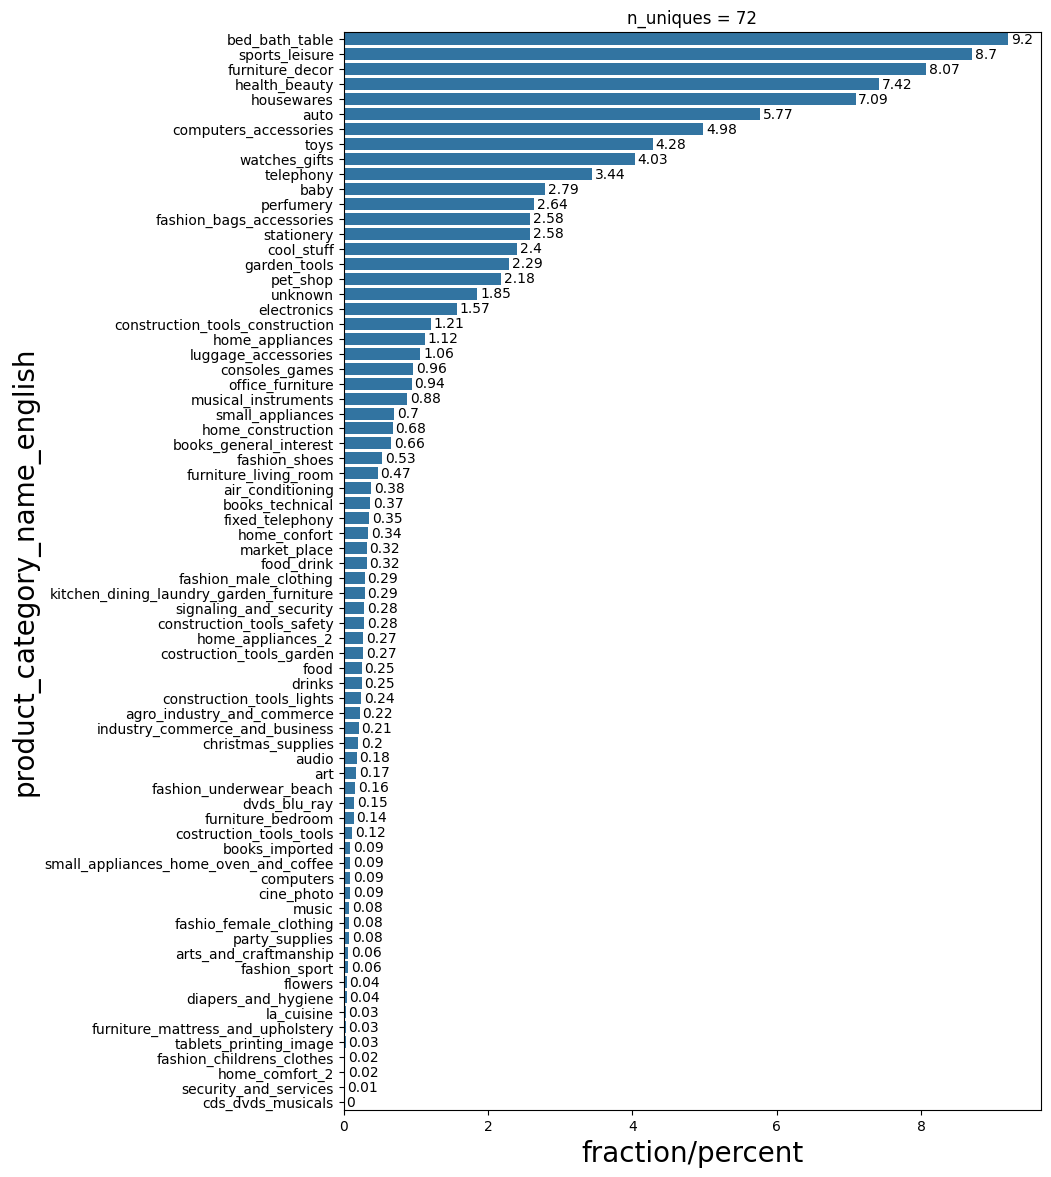

In [145]:
UVA.category(products, ['product_category_name_english'], 9, 14)

### process by customer

In [146]:
#ord_df.head()

In [147]:
#products.head()

In [148]:
#matching_table.head()

In [149]:
custo_product = matching_table[['customer_unique_id', 'product_id']]\
    .merge(products[['product_id', 'product_global_category']], on='product_id', how='inner')
custo_product.head()

,customer_unique_id,product_id,product_global_category
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,home
1,3a51803cc0d012c3b5dc8b7528cb05f7,87285b34884572647811a353c7ac498a,home
2,ef0996a1a279c26e7ecbd737be23d235,87285b34884572647811a353c7ac498a,home
3,02c9e0c05a817d4562ec0e8c90f29dba,b00a32a0b42fd65efb58a5822009f629,health_beauty
4,28adbfbaf0b9c5e5a0555a8c853a7534,b00a32a0b42fd65efb58a5822009f629,health_beauty


In [150]:
# check custo_product nans
custo_product.isna().sum()

customer_unique_id         0
product_id                 0
product_global_category    4
dtype: int64

In [151]:
custo_product.loc[custo_product['product_global_category'].isna()]

,customer_unique_id,product_id,product_global_category
11310,949921a7831eb8901f75baf57d1853bf,0105b5323d24fc655f73052694dbbb3a,NaN
11311,28d9650a4a5f00fcc716da5ee2460012,0105b5323d24fc655f73052694dbbb3a,NaN
11312,b25c62ba4fc28e41117f8026bf9a31b5,0105b5323d24fc655f73052694dbbb3a,NaN
11313,b70d126df03b594cb148da07860d1534,0105b5323d24fc655f73052694dbbb3a,NaN


In [152]:
# fill the 24 lines with NaN global categories : unknown
custo_product['product_global_category'].fillna("unknown", inplace=True)
custo_product['product_global_category'].isnull().value_counts()

False    33803
Name: product_global_category, dtype: int64

In [153]:
#custo_product.groupby(['customer_unique_id', 'product_global_category']).size().reset_index(name="counts")

In [154]:
df_cus_cat = custo_product[['customer_unique_id', 'product_global_category']].value_counts().reset_index(name="counts")
df_cus_cat.head()

,customer_unique_id,product_global_category,counts
0,d97b3cfb22b0d6b25ac9ed4e9c2d481b,furniture,24
1,4546caea018ad8c692964e3382debd19,health_beauty,21
2,11f97da02237a49c8e783dfda6f50e8e,garden,15
3,2e43e031f10de28e557c35ef668f9396,sports_leisure,12
4,86df00dc5fd68f4dd5d5945ca19f3ed6,electronics,12


In [155]:
custo_product

,customer_unique_id,product_id,product_global_category
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,home
1,3a51803cc0d012c3b5dc8b7528cb05f7,87285b34884572647811a353c7ac498a,home
2,ef0996a1a279c26e7ecbd737be23d235,87285b34884572647811a353c7ac498a,home
3,02c9e0c05a817d4562ec0e8c90f29dba,b00a32a0b42fd65efb58a5822009f629,health_beauty
4,28adbfbaf0b9c5e5a0555a8c853a7534,b00a32a0b42fd65efb58a5822009f629,health_beauty
...,...,...,...
33798,bd0a735ae91504c00c71638c720e3cca,24fcd474105d95d2002f38f0cacf87ee,auto
33799,6ee4fdb7edab032aaa8392bab5446546,654ccc4e5459e7ba6b8d9fb04c45b9db,books_stationery
33800,78a159045124eb7601951b917a42034f,241a1ffc9cf969b27de6e72301020268,auto
33801,1c2f7913bdd5d4d75b81a664d14b7fc7,0504d5c0f9b71510b2b0bee952e380fa,furniture


#### feature variance filtering

##### prepare monetary values per customer on categories

In [156]:
# pivot and merge all categories details
df_cus_cat_pivot = df_cus_cat.pivot_table(index=['customer_unique_id']
                                            ,columns='product_global_category'
                                            ,values='counts'
                                           )\
                    .reset_index()\
                    .rename_axis(None, axis=1)\
                    .fillna(0)
# unstack('product_global_category')
pivot_num_cols = df_cus_cat_pivot.select_dtypes(include=np.number).columns.to_list()
df_cus_cat_pivot[pivot_num_cols] = df_cus_cat_pivot[pivot_num_cols].astype(np.int64)
df_cus_cat_pivot

,customer_unique_id,auto,books_stationery,construction,electronics,fashion,furniture,garden,health_beauty,home,misc,sports_leisure,toys_gifts,unknown
0,0000f46a3911fa3c0805444483337064,0,1,0,0,0,0,0,0,0,0,0,0,0
1,0000f6ccb0745a6a4b88665a16c9f078,0,0,0,1,0,0,0,0,0,0,0,0,0
2,0005e1862207bf6ccc02e4228effd9a0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,0006fdc98a402fceb4eb0ee528f6a8d4,0,0,0,0,0,1,0,0,0,0,0,0,0
4,000a5ad9c4601d2bbdd9ed765d5213b3,0,0,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28621,fff3a9369e4b7102fab406a334a678c3,0,0,0,0,0,0,0,0,0,1,0,0,0
28622,fff699c184bcc967d62fa2c6171765f7,0,0,0,0,0,0,0,0,0,0,1,0,0
28623,fffcf5a5ff07b0908bd4e2dbc735a684,0,0,0,0,0,0,0,2,0,0,0,0,0
28624,ffff371b4d645b6ecea244b27531430a,1,0,0,0,0,0,0,0,0,0,0,0,0


In [157]:
# change focus : monetary value per sub-category rather than order count per main category :

In [158]:
custo_product_all_cat = matching_table[['customer_unique_id', 'product_id', 'order_id', 'price']]\
    .merge(products[['product_id', 'product_category_name_english']], on='product_id', how='inner')
custo_product_all_cat.head()

,customer_unique_id,product_id,order_id,price,product_category_name_english
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,e481f51cbdc54678b7cc49136f2d6af7,29.99,housewares
1,3a51803cc0d012c3b5dc8b7528cb05f7,87285b34884572647811a353c7ac498a,128e10d95713541c87cd1a2e48201934,29.99,housewares
2,ef0996a1a279c26e7ecbd737be23d235,87285b34884572647811a353c7ac498a,0e7e841ddf8f8f2de2bad69267ecfbcf,29.99,housewares
3,02c9e0c05a817d4562ec0e8c90f29dba,b00a32a0b42fd65efb58a5822009f629,8736140c61ea584cb4250074756d8f3b,75.90,baby
4,28adbfbaf0b9c5e5a0555a8c853a7534,b00a32a0b42fd65efb58a5822009f629,88407c8c6e12493ff6e845df39540112,75.90,baby


In [159]:
custo_product_all_cat.isna().sum()

customer_unique_id               0
product_id                       0
order_id                         0
price                            0
product_category_name_english    4
dtype: int64

In [160]:
matching_table.duplicated().sum()

0

In [161]:
custo_product_all_cat.duplicated().sum()

3207

In [162]:
custo_product_all_cat[custo_product_all_cat.duplicated()]

,customer_unique_id,product_id,order_id,price,product_category_name_english
9,8cafc4a24a917c4a9084b763a82baf66,b00a32a0b42fd65efb58a5822009f629,e3cc61bbc1cfe072879400a8d82f10a2,79.9,baby
85,065dd01c6b43b086b22fdc329552d765,060cb19345d90064d1015407193c233d,b3f3f413f89e281887189ce9f68f4ff9,147.9,auto
88,3abdf4f27efce96f8573a88343a4084e,fd424396761d9e1609c5516b7d8ce17b,9d513821c0477231fc7c1bfd684d13d8,80.4,auto
110,cc14ea7099959d91a17c9d7c3a46721d,a50acd33ba7a8da8e9db65094fa990a4,c4ca4450ac2974ba5eeb4832b7ec724a,117.3,auto
234,cc14ea7099959d91a17c9d7c3a46721d,98d61056e0568ba048e5d78038790e77,c4ca4450ac2974ba5eeb4832b7ec724a,169.0,auto
...,...,...,...,...,...
33788,dfe96ce580a21f177c1d85fe2c78e1ab,de7087431dce1f95bf39105df32825cd,26c2b0e7dd3eb988721bb042f783c80e,59.9,sports_leisure
33789,dfe96ce580a21f177c1d85fe2c78e1ab,de7087431dce1f95bf39105df32825cd,26c2b0e7dd3eb988721bb042f783c80e,59.9,sports_leisure
33790,dfe96ce580a21f177c1d85fe2c78e1ab,de7087431dce1f95bf39105df32825cd,26c2b0e7dd3eb988721bb042f783c80e,59.9,sports_leisure
33791,dfe96ce580a21f177c1d85fe2c78e1ab,de7087431dce1f95bf39105df32825cd,26c2b0e7dd3eb988721bb042f783c80e,59.9,sports_leisure


In [163]:
# not dropping duplicates, considering it's possible to buy multiple of the same product_id within the same order
#custo_product_all_cat.drop_duplicates(inplace=True)
print(custo_product_all_cat.duplicated().sum())
print(custo_product_all_cat.shape)

3207
(33803, 5)


In [164]:
# agg per customer_unique_id : total sum/price per category
all_cat_monetary = custo_product_all_cat.groupby(['customer_unique_id', 'product_category_name_english'])['price'].sum().reset_index()


In [165]:
df_cus_all_cat_pivot = all_cat_monetary.pivot_table(index=['customer_unique_id']
                                            ,columns='product_category_name_english'
                                            ,values='price'
                                           )\
                    .rename_axis(None, axis=1)\
                    .fillna(0)
df_cus_all_cat_pivot

,agro_industry_and_commerce,air_conditioning,art,arts_and_craftmanship,audio,auto,baby,bed_bath_table,books_general_interest,books_imported,books_technical,cds_dvds_musicals,christmas_supplies,cine_photo,computers,computers_accessories,consoles_games,construction_tools_construction,construction_tools_lights,construction_tools_safety,cool_stuff,costruction_tools_garden,costruction_tools_tools,diapers_and_hygiene,drinks,dvds_blu_ray,electronics,fashio_female_clothing,fashion_bags_accessories,fashion_childrens_clothes,fashion_male_clothing,fashion_shoes,fashion_sport,fashion_underwear_beach,fixed_telephony,food,food_drink,furniture_bedroom,furniture_decor,furniture_living_room,furniture_mattress_and_upholstery,garden_tools,health_beauty,home_appliances,home_appliances_2,home_comfort_2,home_confort,home_construction,housewares,industry_commerce_and_business,kitchen_dining_laundry_garden_furniture,la_cuisine,luggage_accessories,market_place,music,musical_instruments,office_furniture,party_supplies,perfumery,pet_shop,security_and_services,signaling_and_security,small_appliances,small_appliances_home_oven_and_coffee,sports_leisure,stationery,tablets_printing_image,telephony,toys,unknown,watches_gifts
customer_unique_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0000f46a3911fa3c0805444483337064,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,69.0,0.0,0.00,0.0,0.0,0.0
0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.99,0.0,0.0,0.0
0005e1862207bf6ccc02e4228effd9a0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,135.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
0006fdc98a402fceb4eb0ee528f6a8d4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,13.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
000a5ad9c4601d2bbdd9ed765d5213b3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
fff3a9369e4b7102fab406a334a678c3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,84.9,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
fff699c184bcc967d62fa2c6171765f7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0
fffcf5a5ff07b0908bd4e2dbc735a684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,

In [166]:
print(df_cus_all_cat_pivot.isna().sum().sum())
print(df_cus_all_cat_pivot.duplicated().sum())

0
19301


In [167]:
cols_list = df_cus_all_cat_pivot.columns
len(cols_list)

71

In [168]:
kept_cols = ['auto', 'baby', 'bed_bath_table', 'computers', 'computers_accessories',
       'cool_stuff', 'fixed_telephony', 'furniture_decor', 'garden_tools',
       'health_beauty', 'home_appliances_2', 'housewares',
       'musical_instruments', 'office_furniture', 'small_appliances',
       'sports_leisure', 'telephony', 'toys', 'watches_gifts']
kept_cols

['auto',
 'baby',
 'bed_bath_table',
 'computers',
 'computers_accessories',
 'cool_stuff',
 'fixed_telephony',
 'furniture_decor',
 'garden_tools',
 'health_beauty',
 'home_appliances_2',
 'housewares',
 'musical_instruments',
 'office_furniture',
 'small_appliances',
 'sports_leisure',
 'telephony',
 'toys',
 'watches_gifts']

In [169]:
df_reduced = df_cus_all_cat_pivot[kept_cols]
df_reduced.head()

,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts
customer_unique_id,,,,,,,,,,,,,,,,,,,
0000f46a3911fa3c0805444483337064,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,25.99,0.0,0.0
0005e1862207bf6ccc02e4228effd9a0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
0006fdc98a402fceb4eb0ee528f6a8d4,0.0,0.0,13.9,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
000a5ad9c4601d2bbdd9ed765d5213b3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.99,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0


In [170]:
pivot_cols = df_cus_all_cat_pivot.columns.tolist()
others_merge_columns = [col for col in pivot_cols if col not in kept_cols]

In [171]:
print(len(kept_cols))
print(len(others_merge_columns))
print(df_cus_all_cat_pivot.shape[1])

19
52
71


In [172]:
merge_others_cat = df_cus_all_cat_pivot[others_merge_columns].sum(axis=1).reset_index().rename(columns={0:"other_categories"})
merge_others_cat

,customer_unique_id,other_categories
0,0000f46a3911fa3c0805444483337064,69.00
1,0000f6ccb0745a6a4b88665a16c9f078,0.00
2,0005e1862207bf6ccc02e4228effd9a0,135.00
3,0006fdc98a402fceb4eb0ee528f6a8d4,0.00
4,000a5ad9c4601d2bbdd9ed765d5213b3,0.00
...,...,...
28617,fff3a9369e4b7102fab406a334a678c3,84.90
28618,fff699c184bcc967d62fa2c6171765f7,39.90
28619,fffcf5a5ff07b0908bd4e2dbc735a684,0.00
28620,ffff371b4d645b6ecea244b27531430a,0.00


In [173]:
df_cat_pivot_reduc = df_cus_all_cat_pivot[kept_cols].merge(merge_others_cat, on = 'customer_unique_id', how= 'left')
df_cat_pivot_reduc

,customer_unique_id,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories
0,0000f46a3911fa3c0805444483337064,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,69.00
1,0000f6ccb0745a6a4b88665a16c9f078,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,25.99,0.0,0.0,0.00
2,0005e1862207bf6ccc02e4228effd9a0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,135.00
3,0006fdc98a402fceb4eb0ee528f6a8d4,0.0,0.0,13.9,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00
4,000a5ad9c4601d2bbdd9ed765d5213b3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,76.99,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28617,fff3a9369e4b7102fab406a334a678c3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,84.90
28618,fff699c184bcc967d62fa2c6171765f7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,39.90
28619,fffcf5a5ff07b0908bd4e2dbc735a684,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1570.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00
28620,ffff371b4d645b6ecea244b27531430a,89.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.00


In [174]:
# check variance of merged column :
np.var(df_cat_pivot_reduc['other_categories'])

10271.444939220324

In [175]:
# check individual variance of columns to merge :
np.var(df_cus_all_cat_pivot[others_merge_columns]).sort_values(ascending=False)

unknown                                    1699.652366
art                                        1488.493006
perfumery                                  1268.909458
consoles_games                             1036.968294
pet_shop                                    978.651566
air_conditioning                            477.003363
luggage_accessories                         472.854378
fashion_bags_accessories                    407.263824
electronics                                 365.881454
stationery                                  275.645559
home_confort                                242.503494
furniture_living_room                       241.501524
market_place                                240.414522
agro_industry_and_commerce                  205.979302
home_construction                           203.523697
dvds_blu_ray                                164.735249
home_appliances                             149.748637
industry_commerce_and_business              138.458641
furniture_

In [176]:
# merge into dataset
df_customers = df_customers.merge(df_cat_pivot_reduc, on='customer_unique_id', how='left')
df_customers

,customer_unique_id,recency,frequency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories
0,7c396fd4830fd04220f754e42b4e5bff,15,2,0.00,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,29.99,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
1,80bb27c7c16e8f973207a5086ab329e2,100,1,147.90,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
2,36edbb3fb164b1f16485364b6fb04c73,189,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,49.9
3,932afa1e708222e5821dac9cd5db4cae,154,1,59.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
4,39382392765b6dc74812866ee5ee92a7,267,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29197,c716cf2b5b86fb24257cffe9e7969df8,13,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,69.01,0.0,0.0
29198,e03dbdf5e56c96b106d8115ac336f47f,263,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,370.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
29199,831ce3f1bacbd424fc4e38fbd4d66d29,236,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,139.9,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0
29200,6359f309b166b0196dbf7ad2ac62bb5a,222,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0


In [177]:
df_customers.isna().sum()

customer_unique_id         0
recency                    0
frequency                  0
auto                     580
baby                     580
bed_bath_table           580
computers                580
computers_accessories    580
cool_stuff               580
fixed_telephony          580
furniture_decor          580
garden_tools             580
health_beauty            580
home_appliances_2        580
housewares               580
musical_instruments      580
office_furniture         580
small_appliances         580
sports_leisure           580
telephony                580
toys                     580
watches_gifts            580
other_categories         580
dtype: int64

In [178]:
df_customers.duplicated().sum()

0

In [179]:
kept_cols_2 = kept_cols
kept_cols_2.append('other_categories')
kept_cols_2

['auto',
 'baby',
 'bed_bath_table',
 'computers',
 'computers_accessories',
 'cool_stuff',
 'fixed_telephony',
 'furniture_decor',
 'garden_tools',
 'health_beauty',
 'home_appliances_2',
 'housewares',
 'musical_instruments',
 'office_furniture',
 'small_appliances',
 'sports_leisure',
 'telephony',
 'toys',
 'watches_gifts',
 'other_categories']

In [180]:
kept_cols_2

['auto',
 'baby',
 'bed_bath_table',
 'computers',
 'computers_accessories',
 'cool_stuff',
 'fixed_telephony',
 'furniture_decor',
 'garden_tools',
 'health_beauty',
 'home_appliances_2',
 'housewares',
 'musical_instruments',
 'office_furniture',
 'small_appliances',
 'sports_leisure',
 'telephony',
 'toys',
 'watches_gifts',
 'other_categories']

In [181]:
#df_customers_2 = df_customers.copy()
#df_customers_2['monetary_2'] = df_customers_2[kept_cols_2].sum(axis=1)
#df_customers_2.drop(columns=kept_cols_2, inplace=True)
#df_customers_2

In [182]:
#df_customers_2[df_customers_2['monetary']!=df_customers_2['monetary_2']]

In [183]:
#df_customers_2[df_customers_2['monetary']!=df_customers_2['monetary_2']]['customer_unique_id'].nunique()

In [184]:
df_customers.dropna(inplace=True)

In [185]:
df_customers.isna().sum()

customer_unique_id       0
recency                  0
frequency                0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
dtype: int64

#### Main cat per customer

In [186]:
idx = df_cus_cat.groupby(['customer_unique_id'])['product_global_category','counts'].idxmax()
#max_counts = df_cus_cat[idx]

In [187]:
idx = df_cus_cat.groupby('customer_unique_id')['counts'].idxmax()

In [188]:
cus_cat_max = df_cus_cat[df_cus_cat.index.isin(idx)]
cus_cat_max

,customer_unique_id,product_global_category,counts
0,d97b3cfb22b0d6b25ac9ed4e9c2d481b,furniture,24
1,4546caea018ad8c692964e3382debd19,health_beauty,21
2,11f97da02237a49c8e783dfda6f50e8e,garden,15
3,2e43e031f10de28e557c35ef668f9396,sports_leisure,12
4,86df00dc5fd68f4dd5d5945ca19f3ed6,electronics,12
...,...,...,...
29102,594ede005cff2f26d4164325737a49ac,health_beauty,1
29103,594ac9b39870a38d645e8e8171a87638,misc,1
29104,59480732845d7411f4a2406a563c878e,unknown,1
29105,5944277d79c6bb09958fffcfe6552fd9,furniture,1


In [189]:
df_cus_cat['customer_unique_id'].value_counts()

47c1a3033b8b77b3ab6e109eb4d5fdf3    4
39104edef5e46d7b8c61848cc95e6d97    3
4e65032f1f574189fb793bac5a867bbc    3
8c21dd8c37144807c601f99f2a209dfb    3
083ca1aa470c280236380973a48f77c6    3
                                   ..
df2ef00cc9d5b4aff2a4160e293e8525    1
df2f1fa25b60c9de8a418446ebd975d6    1
df328634fd50c8a6ff1531d9408169dd    1
df38102d80095da57461f4e328d3ae7e    1
ffffd2657e2aad2907e67c3e9daecbeb    1
Name: customer_unique_id, Length: 28626, dtype: int64

In [190]:
df_cus_cat.loc[df_cus_cat['customer_unique_id'] == '3e43e6105506432c953e165fb2acf44c']

,customer_unique_id,product_global_category,counts
240,3e43e6105506432c953e165fb2acf44c,furniture,4


In [191]:
cus_cat_max.loc[cus_cat_max['customer_unique_id'] == '8c21dd8c37144807c601f99f2a209dfb']

,customer_unique_id,product_global_category,counts
2524,8c21dd8c37144807c601f99f2a209dfb,fashion,2


In [192]:
cus_cat_max.rename(columns={"product_global_category":"main_category"}, inplace=True)
cus_cat_max

,customer_unique_id,main_category,counts
0,d97b3cfb22b0d6b25ac9ed4e9c2d481b,furniture,24
1,4546caea018ad8c692964e3382debd19,health_beauty,21
2,11f97da02237a49c8e783dfda6f50e8e,garden,15
3,2e43e031f10de28e557c35ef668f9396,sports_leisure,12
4,86df00dc5fd68f4dd5d5945ca19f3ed6,electronics,12
...,...,...,...
29102,594ede005cff2f26d4164325737a49ac,health_beauty,1
29103,594ac9b39870a38d645e8e8171a87638,misc,1
29104,59480732845d7411f4a2406a563c878e,unknown,1
29105,5944277d79c6bb09958fffcfe6552fd9,furniture,1


In [193]:
# merge max_category into
df_customers = df_customers.merge(cus_cat_max[['customer_unique_id', 'main_category']], on='customer_unique_id', how='left')
df_customers

,customer_unique_id,recency,frequency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category
0,7c396fd4830fd04220f754e42b4e5bff,15,2,0.00,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,29.99,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,home
1,80bb27c7c16e8f973207a5086ab329e2,100,1,147.90,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,auto
2,36edbb3fb164b1f16485364b6fb04c73,189,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,49.9,unknown
3,932afa1e708222e5821dac9cd5db4cae,154,1,59.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,auto
4,39382392765b6dc74812866ee5ee92a7,267,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,furniture
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28617,c716cf2b5b86fb24257cffe9e7969df8,13,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,69.01,0.0,0.0,toys_gifts
28618,e03dbdf5e56c96b106d8115ac336f47f,263,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,370.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,health_beauty
28619,831ce3f1bacbd424fc4e38fbd4d66d29,236,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,139.9,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,furniture
28620,6359f309b166b0196dbf7ad2ac62bb5a,222,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,health_beauty


In [194]:
#UVA.category(products, ['product_global_category'], 9, 5)

In [195]:
df_cus_cat

,customer_unique_id,product_global_category,counts
0,d97b3cfb22b0d6b25ac9ed4e9c2d481b,furniture,24
1,4546caea018ad8c692964e3382debd19,health_beauty,21
2,11f97da02237a49c8e783dfda6f50e8e,garden,15
3,2e43e031f10de28e557c35ef668f9396,sports_leisure,12
4,86df00dc5fd68f4dd5d5945ca19f3ed6,electronics,12
...,...,...,...
29102,594ede005cff2f26d4164325737a49ac,health_beauty,1
29103,594ac9b39870a38d645e8e8171a87638,misc,1
29104,59480732845d7411f4a2406a563c878e,unknown,1
29105,5944277d79c6bb09958fffcfe6552fd9,furniture,1


In [196]:
# pivot and merge all categories details
df_cus_cat_pivot = df_cus_cat.pivot_table(index=['customer_unique_id']
                                            ,columns='product_global_category'
                                            ,values='counts'
                                           )\
                    .reset_index()\
                    .rename_axis(None, axis=1)\
                    .fillna(0)
# unstack('product_global_category')
pivot_num_cols = df_cus_cat_pivot.select_dtypes(include=np.number).columns.to_list()
df_cus_cat_pivot[pivot_num_cols] = df_cus_cat_pivot[pivot_num_cols].astype(np.int64)
df_cus_cat_pivot

,customer_unique_id,auto,books_stationery,construction,electronics,fashion,furniture,garden,health_beauty,home,misc,sports_leisure,toys_gifts,unknown
0,0000f46a3911fa3c0805444483337064,0,1,0,0,0,0,0,0,0,0,0,0,0
1,0000f6ccb0745a6a4b88665a16c9f078,0,0,0,1,0,0,0,0,0,0,0,0,0
2,0005e1862207bf6ccc02e4228effd9a0,0,0,0,0,1,0,0,0,0,0,0,0,0
3,0006fdc98a402fceb4eb0ee528f6a8d4,0,0,0,0,0,1,0,0,0,0,0,0,0
4,000a5ad9c4601d2bbdd9ed765d5213b3,0,0,0,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28621,fff3a9369e4b7102fab406a334a678c3,0,0,0,0,0,0,0,0,0,1,0,0,0
28622,fff699c184bcc967d62fa2c6171765f7,0,0,0,0,0,0,0,0,0,0,1,0,0
28623,fffcf5a5ff07b0908bd4e2dbc735a684,0,0,0,0,0,0,0,2,0,0,0,0,0
28624,ffff371b4d645b6ecea244b27531430a,1,0,0,0,0,0,0,0,0,0,0,0,0


## Freight value

In [197]:
df_freight_value = ord_df.groupby('customer_unique_id')['freight_value'].sum().reset_index()
df_freight_value

,customer_unique_id,freight_value
0,0000f46a3911fa3c0805444483337064,17.22
1,0000f6ccb0745a6a4b88665a16c9f078,17.63
2,0005e1862207bf6ccc02e4228effd9a0,15.12
3,0006fdc98a402fceb4eb0ee528f6a8d4,15.10
4,000a5ad9c4601d2bbdd9ed765d5213b3,14.29
...,...,...
28853,fff3a9369e4b7102fab406a334a678c3,17.84
28854,fff699c184bcc967d62fa2c6171765f7,15.10
28855,fffcf5a5ff07b0908bd4e2dbc735a684,497.42
28856,ffff371b4d645b6ecea244b27531430a,22.56


In [198]:
df_customers = df_customers.merge(df_freight_value, on='customer_unique_id')
df_customers

,customer_unique_id,recency,frequency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value
0,7c396fd4830fd04220f754e42b4e5bff,15,2,0.00,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,29.99,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,home,17.44
1,80bb27c7c16e8f973207a5086ab329e2,100,1,147.90,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,auto,27.36
2,36edbb3fb164b1f16485364b6fb04c73,189,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,49.9,unknown,16.05
3,932afa1e708222e5821dac9cd5db4cae,154,1,59.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,auto,15.17
4,39382392765b6dc74812866ee5ee92a7,267,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,furniture,16.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28617,c716cf2b5b86fb24257cffe9e7969df8,13,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,69.01,0.0,0.0,toys_gifts,37.78
28618,e03dbdf5e56c96b106d8115ac336f47f,263,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,370.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,health_beauty,19.43
28619,831ce3f1bacbd424fc4e38fbd4d66d29,236,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,139.9,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,furniture,16.09
28620,6359f309b166b0196dbf7ad2ac62bb5a,222,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,health_beauty,13.08


In [199]:
df_customers.isna().sum()

customer_unique_id       0
recency                  0
frequency                0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
dtype: int64

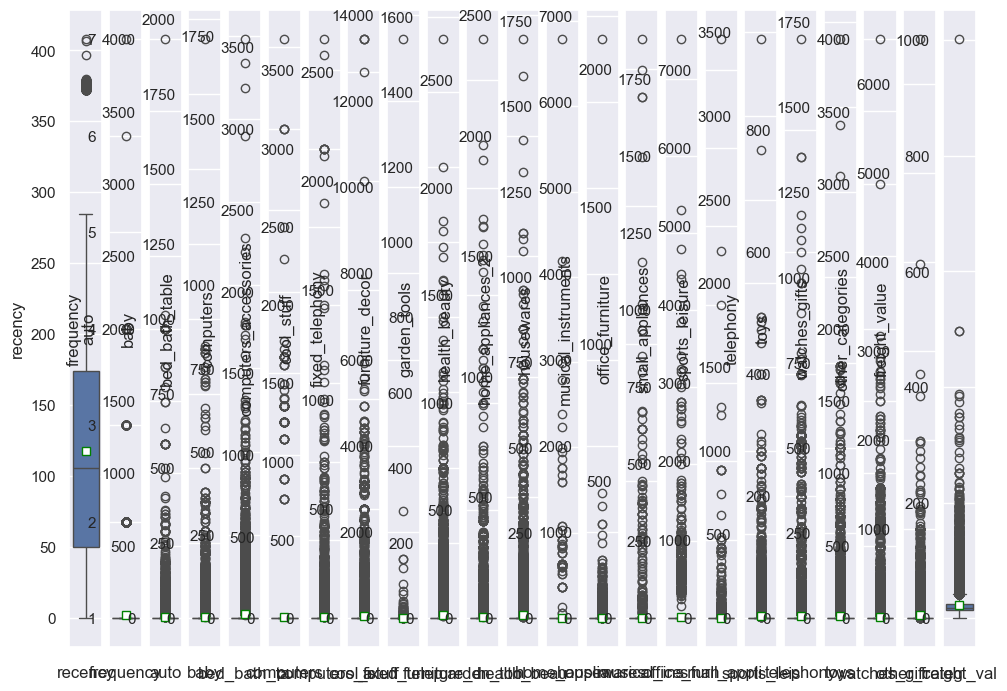

In [200]:
num_cols = df_customers.select_dtypes(include=np.number).columns.to_list()
MVA.boxplot_nums(df_customers, num_cols)

### weight / length / heigh / width

#### New method : bins and count per category

In [201]:
#products[products.product_weight_g.isna()]

In [202]:
#products.drop(products[products.product_weight_g.isna()].index, inplace=True)

In [203]:
products.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [204]:
# bin products by weight : light / medium / heavy
# https://www.geeksforgeeks.org/how-to-use-pandas-cut-and-qcut/
products['weight_qcut'] = pd.qcut(products['product_weight_g'], q=3
                                  ,labels = ['light'
                                             ,'medium'
                                             ,'heavy'
                                          ]
                                 )
products.head()

,product_id,product_category_name,product_category_name_english,product_global_category,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,weight_qcut
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,perfumery,health_beauty,40.0,287.0,1.0,225.0,16.0,10.0,14.0,light
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,art,sports_leisure,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,medium
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,sports_leisure,sports_leisure,46.0,250.0,1.0,154.0,18.0,9.0,15.0,light
3,cef67bcfe19066a932b7673e239eb23d,bebes,baby,health_beauty,27.0,261.0,1.0,371.0,26.0,4.0,26.0,light
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,housewares,home,37.0,402.0,4.0,625.0,20.0,17.0,13.0,medium


In [205]:
# bins value details
pd.qcut(products['product_weight_g'], q=3).value_counts()

(-0.001, 400.0]      11338
(400.0, 1300.0]      10878
(1300.0, 40425.0]    10733
Name: product_weight_g, dtype: int64

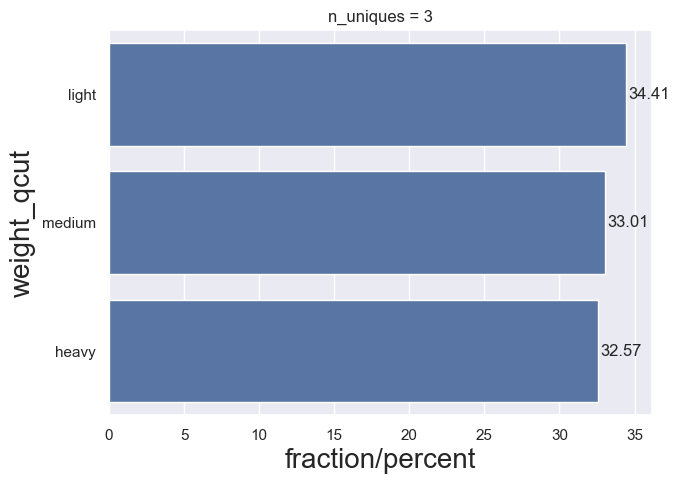

In [206]:
UVA.category(products,['weight_qcut'])

In [207]:
matching_table = matching_table.merge(products[['product_id','weight_qcut']], on='product_id', how='left')

In [208]:
matching_table

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,weight_qcut
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11,2017-10-12 03:43:48,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP,medium
1,8736140c61ea584cb4250074756d8f3b,ab8844663ae049fda8baf15fc928f47f,delivered,2017-08-10 13:35:55,2017-08-10 13:50:09,2017-08-11 13:52:35,2017-08-16 19:03:36,2017-08-23,02c9e0c05a817d4562ec0e8c90f29dba,8577,itaquaquecetuba,SP,b8238c6515192f8129081e17dc57d169,5,NaN,"custo beneficio, simples de usar e rápido",2017-08-17,2017-08-21 12:43:27,1,b00a32a0b42fd65efb58a5822009f629,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-16 13:50:09,75.90,7.79,9350,maua,SP,light
2,a0151737f2f0c6c0a5fd69d45f66ceea,fc2697314ab7fbeda62bb6f1afa4efcd,delivered,2017-07-12 14:11:58,2017-07-12 14:30:18,2017-07-13 12:47:05,2017-07-18 16:24:42,2017-07-25,bdd30e6e39cc70dde8665187b57af402,13820,jaguariuna,SP,fa5bf792d42ed25f80c54d18aeaa83de,4,NaN,NaN,2017-07-19,2017-07-24 13:59:59,1,725cbfcaff95a4d43742fdf13cf43c75,3504c0cb71d7fa48d967e0e4c94d59d9,2017-07-18 14:30:18,44.99,7.78,9350,maua,SP,heavy
3,a3bf941183211246f0d42ad757cba127,3718e1873d5dc3e8d96c0ab783278b02,delivered,2017-07-24 22:16:25,2017-07-25 22:25:11,2017-07-26 14:57:42,2017-07-28 19:06:46,2017-08-04,1bcb517dc3cc80868d2fa941174f386c,6298,osasco,SP,5fe3f65882f521f0fbc41e59b9fbff24,4,NaN,NaN,2017-07-29,2017-08-01 20:06:40,1,725cbfcaff95a4d43742fdf13cf43c75,3504c0cb71d7fa48d967e0e4c94d59d9,2017-07-31 22:25:11,44.99,7.78,9350,maua,SP,heavy
4,1462290799412b71be32dd880eaf4e1b,220e4b027f0294fd79d2869ef67e7db6,delivered,2017-08-19 14:06:58,2017-08-22 04:10:55,2017-08-23 13:54:29,2017-08-29 19:35:06,2017-09-15,123ae28184c9e80638e71d40e37adc27,94130,gravatai,RS,36f6f70dc5e67e8e43b109cae0e92d40,4,NaN,É garantido e de confiança .,2017-08-30,2017-08-31 02:21:39,1,d7faab3fa0091d1220a8ada9cae1bab3,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-28 04:10:55,29.90,14.10,9350,maua,SP,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33798,39e89b39b5cc8b5e3a38f23e915d1823,2b91bc260dcffbdacd12c4b09e5c7463,delivered,2017-07-24 11:29:43,2017-07-24 11:43:21,2017-07-24 22:34:38,2017-08-10 19:42:10,2017-08-23,bd0a735ae91504c00c71638c720e3cca,45051,vitoria da conquista,BA,e6de6c25dc2f6e602c1227e20756c992,5,NaN,NaN,2017-08-11,2017-08-16 14:34:55,1,24fcd474105d95d2002f38f0cacf87ee,72c73be2b085b9d57650dd53eb2004c9,2017-07-28 11:43:21,29.40,17.92,2116,sao paulo,SP,medium
33799,fbff77db5421bb7e1da292db45d07e75,7795e3faa6e16fc40aafee568b25a85d,delivered,2017-03-15 11:41:46,2017-03-15 11:41:46,2017-03-16 04:19:03,2017-03-20 10:34:54,2017-04-03,6ee4fdb7edab032aaa8392bab5446546,9060,santo andre,SP,c13d0d31c88734e32cd3067bf14d34d7,5,NaN,NaN,2017-03-21,2017-03-23 00:59:49,1,654ccc4e5459e7ba6b8d9fb04c45b9db,2d8cfba3fcd3170555941605edaa196a,2017-03-21 11:41:46,45.00,10.96,6080,osasco,SP,light
33800,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaT,NaT,2017-03-30,78a159045124eb7601951b917a42034f,89111,gaspar,SC,c950324a42c5796d06f569f77d8b2e88,1,NaN,NaN,2017-04

In [209]:
weight_cat_ord_count = matching_table.groupby(['customer_unique_id', 'weight_qcut'])['order_id'].nunique().reset_index()
weight_cat_ord_count.rename(columns={'order_id':"count_orders"}, inplace=True)
weight_cat_ord_count

,customer_unique_id,weight_qcut,count_orders
0,0000f46a3911fa3c0805444483337064,light,0
1,0000f46a3911fa3c0805444483337064,medium,0
2,0000f46a3911fa3c0805444483337064,heavy,1
3,0000f6ccb0745a6a4b88665a16c9f078,light,1
4,0000f6ccb0745a6a4b88665a16c9f078,medium,0
...,...,...,...
85873,ffff371b4d645b6ecea244b27531430a,medium,1
85874,ffff371b4d645b6ecea244b27531430a,heavy,0
85875,ffffd2657e2aad2907e67c3e9daecbeb,light,1
85876,ffffd2657e2aad2907e67c3e9daecbeb,medium,0


In [210]:
### pivot and merge all qcut orders_count details
weight_cat_pivot = weight_cat_ord_count.pivot_table(index=['customer_unique_id']
                                            ,columns='weight_qcut'
                                            ,values='count_orders'
                                           )\
                    .reset_index()\
                    .rename_axis(None, axis=1)\
                    .fillna(0)

weight_cat_pivot.rename(columns={'light':'frequency_light', 'medium':'frequency_medium', 'heavy':'frequency_heavy'}, inplace=True)
weight_cat_pivot

,customer_unique_id,frequency_light,frequency_medium,frequency_heavy
0,0000f46a3911fa3c0805444483337064,0,0,1
1,0000f6ccb0745a6a4b88665a16c9f078,1,0,0
2,0005e1862207bf6ccc02e4228effd9a0,0,0,1
3,0006fdc98a402fceb4eb0ee528f6a8d4,1,0,0
4,000a5ad9c4601d2bbdd9ed765d5213b3,0,1,0
...,...,...,...,...
28621,fff3a9369e4b7102fab406a334a678c3,0,0,1
28622,fff699c184bcc967d62fa2c6171765f7,1,0,0
28623,fffcf5a5ff07b0908bd4e2dbc735a684,0,0,1
28624,ffff371b4d645b6ecea244b27531430a,0,1,0


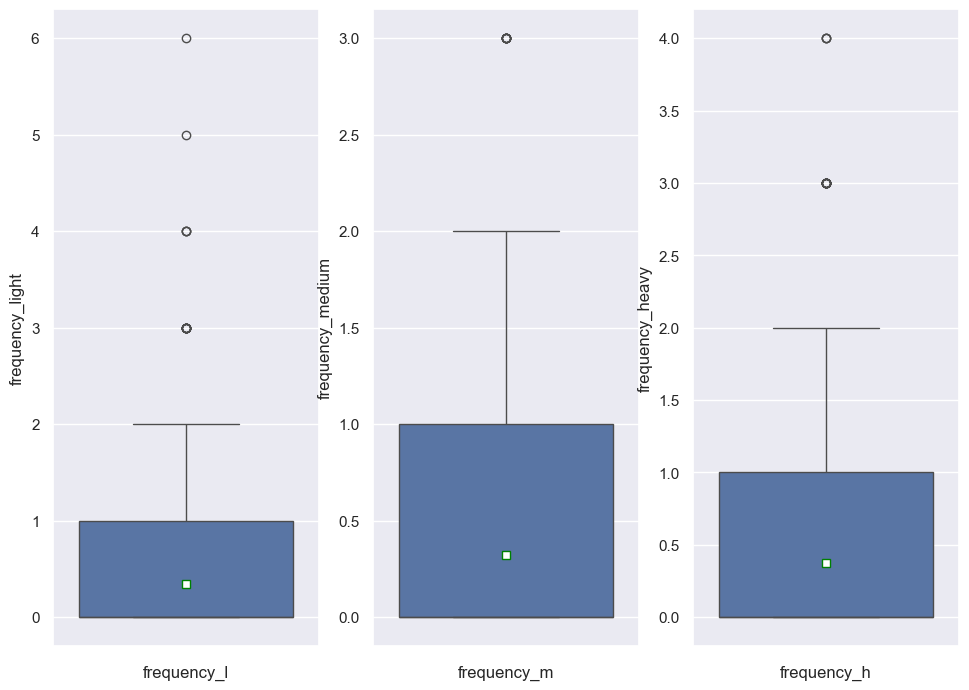

In [211]:
num_cols_cat_pivot = weight_cat_pivot.select_dtypes(include=np.number).columns.to_list()
MVA.boxplot_nums(weight_cat_pivot, num_cols_cat_pivot)

In [212]:
weight_cat_pivot[num_cols_cat_pivot].sum()

frequency_light      9913
frequency_medium     9151
frequency_heavy     10689
dtype: int64

In [213]:
weight_cat_pivot.describe()

,frequency_light,frequency_medium,frequency_heavy
count,28626.000000,28626.000000,28626.000000
mean,0.346294,0.319674,0.373402
std,0.494235,0.477243,0.499212
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,1.000000,1.000000,1.000000
max,6.000000,3.000000,4.000000


In [214]:
df_customers

,customer_unique_id,recency,frequency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value
0,7c396fd4830fd04220f754e42b4e5bff,15,2,0.00,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,29.99,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,home,17.44
1,80bb27c7c16e8f973207a5086ab329e2,100,1,147.90,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,auto,27.36
2,36edbb3fb164b1f16485364b6fb04c73,189,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,49.9,unknown,16.05
3,932afa1e708222e5821dac9cd5db4cae,154,1,59.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,auto,15.17
4,39382392765b6dc74812866ee5ee92a7,267,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,furniture,16.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28617,c716cf2b5b86fb24257cffe9e7969df8,13,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,69.01,0.0,0.0,toys_gifts,37.78
28618,e03dbdf5e56c96b106d8115ac336f47f,263,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,370.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,health_beauty,19.43
28619,831ce3f1bacbd424fc4e38fbd4d66d29,236,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,139.9,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,furniture,16.09
28620,6359f309b166b0196dbf7ad2ac62bb5a,222,1,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,health_beauty,13.08


In [215]:
df_customers = df_customers.merge(weight_cat_pivot, on='customer_unique_id', how='left')
df_customers.drop(columns=['frequency'], inplace=True) # now redundant column
df_customers.head()

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy
0,7c396fd4830fd04220f754e42b4e5bff,15,0.00,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0
1,80bb27c7c16e8f973207a5086ab329e2,100,147.90,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,27.36,0,0,1
2,36edbb3fb164b1f16485364b6fb04c73,189,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.9,unknown,16.05,0,1,0
3,932afa1e708222e5821dac9cd5db4cae,154,59.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,15.17,1,0,0
4,39382392765b6dc74812866ee5ee92a7,267,0.00,0.00,0.0,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,furniture,16.05,1,0,0


## Sellers

In [216]:
sellers.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [217]:
sellers.isna().sum()

seller_id                 0
seller_zip_code_prefix    0
seller_city               0
seller_state              0
dtype: int64

In [218]:
sellers.duplicated().sum()

0

In [219]:
sellers['seller_id'].duplicated().sum()

0

In [220]:
matching_table

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,seller_zip_code_prefix,seller_city,seller_state,weight_qcut
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.",2017-10-11,2017-10-12 03:43:48,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,9350,maua,SP,medium
1,8736140c61ea584cb4250074756d8f3b,ab8844663ae049fda8baf15fc928f47f,delivered,2017-08-10 13:35:55,2017-08-10 13:50:09,2017-08-11 13:52:35,2017-08-16 19:03:36,2017-08-23,02c9e0c05a817d4562ec0e8c90f29dba,8577,itaquaquecetuba,SP,b8238c6515192f8129081e17dc57d169,5,NaN,"custo beneficio, simples de usar e rápido",2017-08-17,2017-08-21 12:43:27,1,b00a32a0b42fd65efb58a5822009f629,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-16 13:50:09,75.90,7.79,9350,maua,SP,light
2,a0151737f2f0c6c0a5fd69d45f66ceea,fc2697314ab7fbeda62bb6f1afa4efcd,delivered,2017-07-12 14:11:58,2017-07-12 14:30:18,2017-07-13 12:47:05,2017-07-18 16:24:42,2017-07-25,bdd30e6e39cc70dde8665187b57af402,13820,jaguariuna,SP,fa5bf792d42ed25f80c54d18aeaa83de,4,NaN,NaN,2017-07-19,2017-07-24 13:59:59,1,725cbfcaff95a4d43742fdf13cf43c75,3504c0cb71d7fa48d967e0e4c94d59d9,2017-07-18 14:30:18,44.99,7.78,9350,maua,SP,heavy
3,a3bf941183211246f0d42ad757cba127,3718e1873d5dc3e8d96c0ab783278b02,delivered,2017-07-24 22:16:25,2017-07-25 22:25:11,2017-07-26 14:57:42,2017-07-28 19:06:46,2017-08-04,1bcb517dc3cc80868d2fa941174f386c,6298,osasco,SP,5fe3f65882f521f0fbc41e59b9fbff24,4,NaN,NaN,2017-07-29,2017-08-01 20:06:40,1,725cbfcaff95a4d43742fdf13cf43c75,3504c0cb71d7fa48d967e0e4c94d59d9,2017-07-31 22:25:11,44.99,7.78,9350,maua,SP,heavy
4,1462290799412b71be32dd880eaf4e1b,220e4b027f0294fd79d2869ef67e7db6,delivered,2017-08-19 14:06:58,2017-08-22 04:10:55,2017-08-23 13:54:29,2017-08-29 19:35:06,2017-09-15,123ae28184c9e80638e71d40e37adc27,94130,gravatai,RS,36f6f70dc5e67e8e43b109cae0e92d40,4,NaN,É garantido e de confiança .,2017-08-30,2017-08-31 02:21:39,1,d7faab3fa0091d1220a8ada9cae1bab3,3504c0cb71d7fa48d967e0e4c94d59d9,2017-08-28 04:10:55,29.90,14.10,9350,maua,SP,medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33798,39e89b39b5cc8b5e3a38f23e915d1823,2b91bc260dcffbdacd12c4b09e5c7463,delivered,2017-07-24 11:29:43,2017-07-24 11:43:21,2017-07-24 22:34:38,2017-08-10 19:42:10,2017-08-23,bd0a735ae91504c00c71638c720e3cca,45051,vitoria da conquista,BA,e6de6c25dc2f6e602c1227e20756c992,5,NaN,NaN,2017-08-11,2017-08-16 14:34:55,1,24fcd474105d95d2002f38f0cacf87ee,72c73be2b085b9d57650dd53eb2004c9,2017-07-28 11:43:21,29.40,17.92,2116,sao paulo,SP,medium
33799,fbff77db5421bb7e1da292db45d07e75,7795e3faa6e16fc40aafee568b25a85d,delivered,2017-03-15 11:41:46,2017-03-15 11:41:46,2017-03-16 04:19:03,2017-03-20 10:34:54,2017-04-03,6ee4fdb7edab032aaa8392bab5446546,9060,santo andre,SP,c13d0d31c88734e32cd3067bf14d34d7,5,NaN,NaN,2017-03-21,2017-03-23 00:59:49,1,654ccc4e5459e7ba6b8d9fb04c45b9db,2d8cfba3fcd3170555941605edaa196a,2017-03-21 11:41:46,45.00,10.96,6080,osasco,SP,light
33800,b159d0ce7cd881052da94fa165617b05,e0c3bc5ce0836b975d6b2a8ce7bb0e3e,canceled,2017-03-11 19:51:36,2017-03-11 19:51:36,NaT,NaT,2017-03-30,78a159045124eb7601951b917a42034f,89111,gaspar,SC,c950324a42c5796d06f569f77d8b2e88,1,NaN,NaN,2017-04

In [221]:
matching_table.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'weight_qcut']

In [222]:
df_sellers_count = matching_table.groupby('customer_unique_id')['seller_id'].nunique().reset_index()
df_sellers_count.columns = ['customer_unique_id','sellers_count']

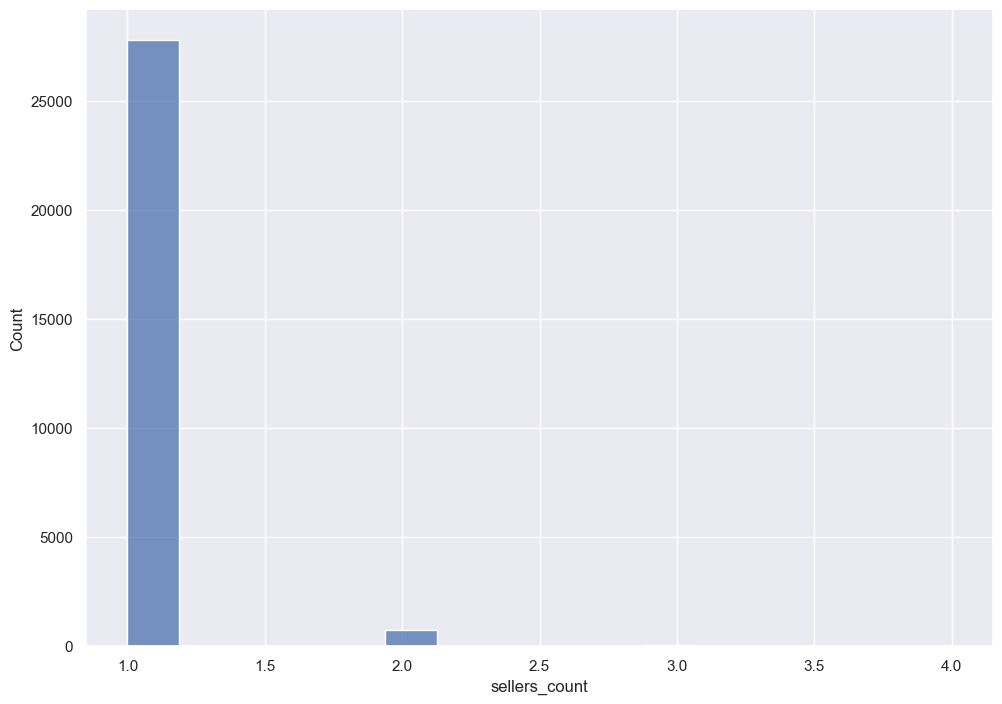

In [223]:
ax = sns.histplot(df_sellers_count['sellers_count'])

In [224]:
# qcut / cut ?

In [225]:
df_customers = df_customers.merge(df_sellers_count, on='customer_unique_id')
df_customers

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count
0,7c396fd4830fd04220f754e42b4e5bff,15,0.00,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,29.99,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,home,17.44,1,1,0,2
1,80bb27c7c16e8f973207a5086ab329e2,100,147.90,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,auto,27.36,0,0,1,1
2,36edbb3fb164b1f16485364b6fb04c73,189,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,49.9,unknown,16.05,0,1,0,1
3,932afa1e708222e5821dac9cd5db4cae,154,59.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,auto,15.17,1,0,0,1
4,39382392765b6dc74812866ee5ee92a7,267,0.00,0.00,0.0,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,furniture,16.05,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28617,c716cf2b5b86fb24257cffe9e7969df8,13,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,69.01,0.0,0.0,toys_gifts,37.78,0,1,0,1
28618,e03dbdf5e56c96b106d8115ac336f47f,263,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,370.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,health_beauty,19.43,0,1,0,1
28619,831ce3f1bacbd424fc4e38fbd4d66d29,236,0.00,0.00,0.0,0.0,0.0,0.0,0.0,139.9,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,furniture,16.09,0,0,1,1
28620,6359f309b166b0196dbf7ad2ac62bb5a,222,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,health_beauty,13.08,0,1,0,1


In [226]:
df_customers.isna().sum()

customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
dtype: int64

## Most frequently bought categories

### main categories

In [227]:
## redundant ?

## Reviews info

### percent review score shared

In [228]:
matching_table.columns.to_list()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'weight_qcut']

In [229]:
ord_df.head()

,order_id,customer_unique_id,total_revenue,freight_value,purchase_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,29.99,8.72,2017-10-02
1,a4591c265e18cb1dcee52889e2d8acc3,80bb27c7c16e8f973207a5086ab329e2,147.90,27.36,2017-07-09
2,136cce7faa42fdb2cefd53fdc79a6098,36edbb3fb164b1f16485364b6fb04c73,49.90,16.05,2017-04-11
3,6514b8ad8028c9f2cc2374ded245783f,932afa1e708222e5821dac9cd5db4cae,59.99,15.17,2017-05-16
4,76c6e866289321a7c93b82b54852dc33,39382392765b6dc74812866ee5ee92a7,19.90,16.05,2017-01-23


In [230]:
reviews.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela Internet seguro e prático Parabéns a todos feliz Páscoa,2018-03-01,2018-03-02 10:26:53


In [231]:
# check reviews

In [232]:
reviews.isna().sum()

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [233]:
score_list = reviews['review_score'].unique().tolist()
score_list.sort()
score_list

[1, 2, 3, 4, 5]

In [234]:
reviews['review_score'].dtype

dtype('int64')

<AxesSubplot:xlabel='review_score', ylabel='Count'>

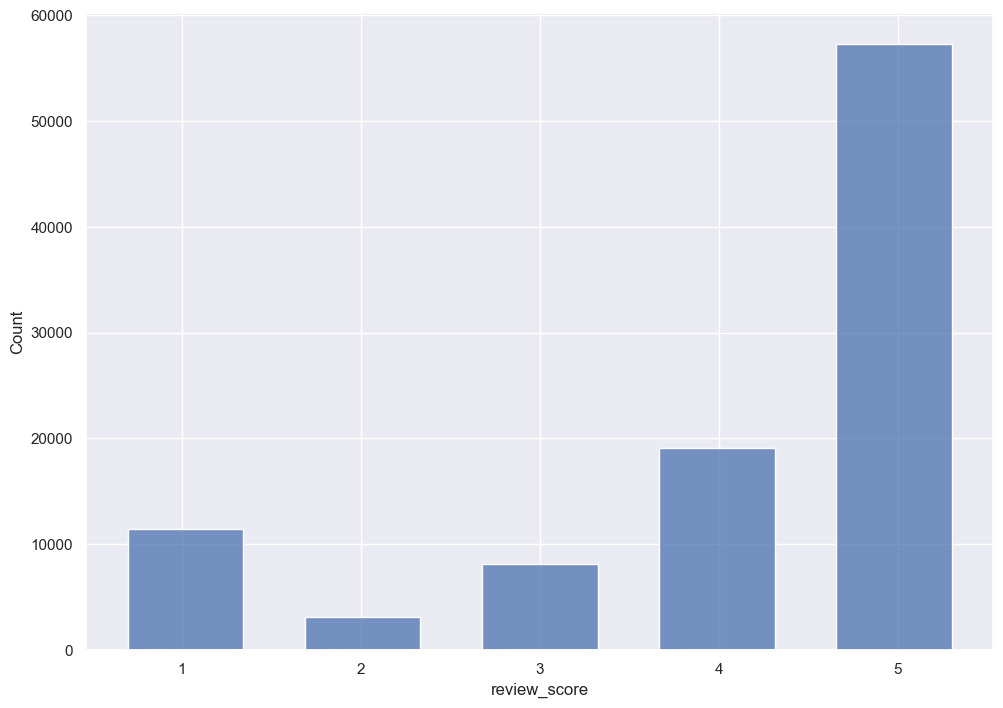

In [235]:
sns.histplot(reviews, x='review_score', shrink=15)

In [236]:
# join/merge tables
custo_reviews = matching_table[['customer_unique_id', 'order_id', 'review_id']]\
            .merge(reviews[['review_id', 'review_score', 'review_comment_message']], on = 'review_id', how='inner')
custo_reviews.head()

,customer_unique_id,order_id,review_id,review_score,review_comment_message
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,a54f0611adc9ed256b57ede6b6eb5114,4,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente."
1,02c9e0c05a817d4562ec0e8c90f29dba,8736140c61ea584cb4250074756d8f3b,b8238c6515192f8129081e17dc57d169,5,"custo beneficio, simples de usar e rápido"
2,bdd30e6e39cc70dde8665187b57af402,a0151737f2f0c6c0a5fd69d45f66ceea,fa5bf792d42ed25f80c54d18aeaa83de,4,NaN
3,1bcb517dc3cc80868d2fa941174f386c,a3bf941183211246f0d42ad757cba127,5fe3f65882f521f0fbc41e59b9fbff24,4,NaN
4,123ae28184c9e80638e71d40e37adc27,1462290799412b71be32dd880eaf4e1b,36f6f70dc5e67e8e43b109cae0e92d40,4,É garantido e de confiança .


In [237]:
custo_reviews.shape

(34646, 5)

In [238]:
mean_review_score = custo_reviews.groupby(['customer_unique_id'])['review_score'].mean().reset_index()
mean_review_score.rename(columns={"review_score":"mean_review_score"}, inplace=True)
mean_review_score

,customer_unique_id,mean_review_score
0,0000f46a3911fa3c0805444483337064,3.0
1,0000f6ccb0745a6a4b88665a16c9f078,4.0
2,0005e1862207bf6ccc02e4228effd9a0,4.0
3,0006fdc98a402fceb4eb0ee528f6a8d4,3.0
4,000a5ad9c4601d2bbdd9ed765d5213b3,4.0
...,...,...
28621,fff3a9369e4b7102fab406a334a678c3,5.0
28622,fff699c184bcc967d62fa2c6171765f7,4.0
28623,fffcf5a5ff07b0908bd4e2dbc735a684,5.0
28624,ffff371b4d645b6ecea244b27531430a,5.0


In [239]:
# check result with customer having multiple orders/reviews => float ?
mean_review_score.loc[mean_review_score['customer_unique_id'] == '3e43e6105506432c953e165fb2acf44c']

,customer_unique_id,mean_review_score
7031,3e43e6105506432c953e165fb2acf44c,2.0


In [240]:
mean_review_score['mean_review_score'].isna().sum()

0

In [241]:
# merge mean_review_score into
df_customers = df_customers.merge(mean_review_score[['customer_unique_id', 'mean_review_score']], on='customer_unique_id', how='left')
df_customers.head()

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score
0,7c396fd4830fd04220f754e42b4e5bff,15,0.00,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0,2,4.5
1,80bb27c7c16e8f973207a5086ab329e2,100,147.90,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,27.36,0,0,1,1,4.0
2,36edbb3fb164b1f16485364b6fb04c73,189,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.9,unknown,16.05,0,1,0,1,2.0
3,932afa1e708222e5821dac9cd5db4cae,154,59.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,15.17,1,0,0,1,5.0
4,39382392765b6dc74812866ee5ee92a7,267,0.00,0.00,0.0,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,furniture,16.05,1,0,0,1,1.0


In [242]:
# check nans
df_customers.loc[df_customers['mean_review_score'].isna()]

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score


In [243]:
# other infos are interesting, inputing mean review score by category to complete

# matching each order main category and review score
product_review = matching_table[['customer_unique_id', 'product_id', 'review_id']]\
    .merge(products[['product_id', 'product_global_category']], on='product_id', how='inner')\
    .merge(reviews[['review_id', 'review_score']])
product_review

,customer_unique_id,product_id,review_id,product_global_category,review_score
0,7c396fd4830fd04220f754e42b4e5bff,87285b34884572647811a353c7ac498a,a54f0611adc9ed256b57ede6b6eb5114,home,4
1,3a51803cc0d012c3b5dc8b7528cb05f7,87285b34884572647811a353c7ac498a,b46f1e34512b0f4c74a72398b03ca788,home,4
2,ef0996a1a279c26e7ecbd737be23d235,87285b34884572647811a353c7ac498a,dc90f19c2806f1abba9e72ad3c350073,home,5
3,02c9e0c05a817d4562ec0e8c90f29dba,b00a32a0b42fd65efb58a5822009f629,b8238c6515192f8129081e17dc57d169,health_beauty,5
4,28adbfbaf0b9c5e5a0555a8c853a7534,b00a32a0b42fd65efb58a5822009f629,186b702b3817fd5cc00b201b11764d63,health_beauty,4
...,...,...,...,...,...
34641,bd0a735ae91504c00c71638c720e3cca,24fcd474105d95d2002f38f0cacf87ee,e6de6c25dc2f6e602c1227e20756c992,auto,5
34642,6ee4fdb7edab032aaa8392bab5446546,654ccc4e5459e7ba6b8d9fb04c45b9db,c13d0d31c88734e32cd3067bf14d34d7,books_stationery,5
34643,78a159045124eb7601951b917a42034f,241a1ffc9cf969b27de6e72301020268,c950324a42c5796d06f569f77d8b2e88,auto,1
34644,1c2f7913bdd5d4d75b81a664d14b7fc7,0504d5c0f9b71510b2b0bee952e380fa,ed152764b4b0041e56affc6e4a795b60,furniture,5


In [244]:
product_review['product_global_category'].isna().sum()

4

In [245]:
product_review['product_global_category'].fillna("unknown", inplace=True)

In [246]:
group_cat = product_review.groupby(by='product_global_category')

In [247]:
mean_review_category = product_review.groupby(by='product_global_category')['review_score'].mean()
mean_review_category

product_global_category
auto                4.037975
books_stationery    4.311268
construction        3.789116
electronics         4.060313
fashion             4.104491
furniture           3.965043
garden              4.136932
health_beauty       4.146652
home                4.123323
misc                4.228713
sports_leisure      4.160782
toys_gifts          4.245100
unknown             3.976636
Name: review_score, dtype: float64

In [248]:
# inputing to df_customers with missing review score : the overall mean review score by category
df_customers['mean_review_score'] = group_cat['review_score'].transform(lambda x: x.fillna(x.mean()))

In [249]:
df_customers

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score
0,7c396fd4830fd04220f754e42b4e5bff,15,0.00,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,29.99,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,home,17.44,1,1,0,2,4
1,80bb27c7c16e8f973207a5086ab329e2,100,147.90,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,auto,27.36,0,0,1,1,4
2,36edbb3fb164b1f16485364b6fb04c73,189,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,49.9,unknown,16.05,0,1,0,1,5
3,932afa1e708222e5821dac9cd5db4cae,154,59.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,auto,15.17,1,0,0,1,5
4,39382392765b6dc74812866ee5ee92a7,267,0.00,0.00,0.0,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,furniture,16.05,1,0,0,1,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28617,c716cf2b5b86fb24257cffe9e7969df8,13,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,69.01,0.0,0.0,toys_gifts,37.78,0,1,0,1,5
28618,e03dbdf5e56c96b106d8115ac336f47f,263,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,370.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,health_beauty,19.43,0,1,0,1,1
28619,831ce3f1bacbd424fc4e38fbd4d66d29,236,0.00,0.00,0.0,0.0,0.0,0.0,0.0,139.9,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,furniture,16.09,0,0,1,1,1
28620,6359f309b166b0196dbf7ad2ac62bb5a,222,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,health_beauty,13.08,0,1,0,1,5


In [250]:
# check nans
df_customers['mean_review_score'].isna().sum()

0

<AxesSubplot:xlabel='mean_review_score', ylabel='Count'>

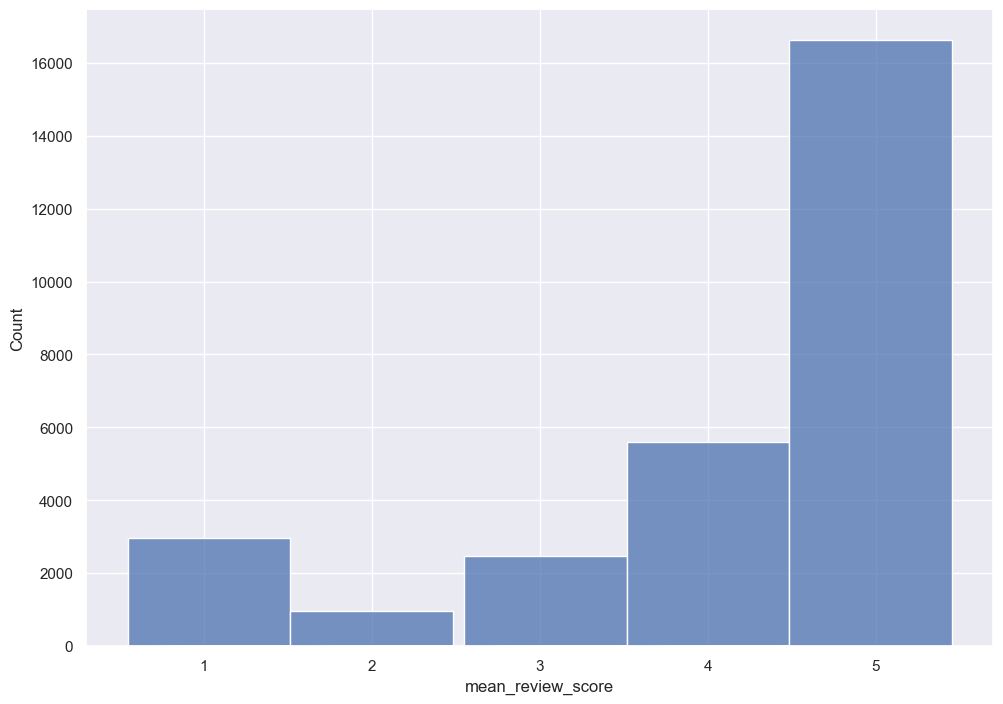

In [251]:
sns.histplot(df_customers, x='mean_review_score', shrink=15)

### percent written review made

In [252]:
custo_reviews['has_comment_message'] = custo_reviews['review_comment_message']
custo_reviews.head()

,customer_unique_id,order_id,review_id,review_score,review_comment_message,has_comment_message
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,a54f0611adc9ed256b57ede6b6eb5114,4,"Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente.","Não testei o produto ainda, mas ele veio correto e em boas condições. Apenas a caixa que veio bem amassada e danificada, o que ficará chato, pois se trata de um presente."
1,02c9e0c05a817d4562ec0e8c90f29dba,8736140c61ea584cb4250074756d8f3b,b8238c6515192f8129081e17dc57d169,5,"custo beneficio, simples de usar e rápido","custo beneficio, simples de usar e rápido"
2,bdd30e6e39cc70dde8665187b57af402,a0151737f2f0c6c0a5fd69d45f66ceea,fa5bf792d42ed25f80c54d18aeaa83de,4,NaN,NaN
3,1bcb517dc3cc80868d2fa941174f386c,a3bf941183211246f0d42ad757cba127,5fe3f65882f521f0fbc41e59b9fbff24,4,NaN,NaN
4,123ae28184c9e80638e71d40e37adc27,1462290799412b71be32dd880eaf4e1b,36f6f70dc5e67e8e43b109cae0e92d40,4,É garantido e de confiança .,É garantido e de confiança .


In [253]:
# count percent of na message per customer_unique_id
ratio_text_review = custo_reviews.groupby('customer_unique_id')['review_comment_message']\
                .apply(lambda x: x.notnull().sum()/len(x)*100).reset_index()

ratio_text_review.head()

,customer_unique_id,review_comment_message
0,0000f46a3911fa3c0805444483337064,0.0
1,0000f6ccb0745a6a4b88665a16c9f078,100.0
2,0005e1862207bf6ccc02e4228effd9a0,0.0
3,0006fdc98a402fceb4eb0ee528f6a8d4,100.0
4,000a5ad9c4601d2bbdd9ed765d5213b3,0.0


In [254]:
ratio_text_review.shape

(28626, 2)

In [255]:
custo_reviews['customer_unique_id'].shape

(34646,)

In [256]:
df_customers = df_customers.merge(ratio_text_review, on='customer_unique_id', how='left')
df_customers.head()

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,review_comment_message
0,7c396fd4830fd04220f754e42b4e5bff,15,0.00,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0,2,4,100.0
1,80bb27c7c16e8f973207a5086ab329e2,100,147.90,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,27.36,0,0,1,1,4,0.0
2,36edbb3fb164b1f16485364b6fb04c73,189,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.9,unknown,16.05,0,1,0,1,5,100.0
3,932afa1e708222e5821dac9cd5db4cae,154,59.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,15.17,1,0,0,1,5,0.0
4,39382392765b6dc74812866ee5ee92a7,267,0.00,0.00,0.0,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,furniture,16.05,1,0,0,1,4,0.0


In [257]:
df_customers.shape

(28622, 30)

In [258]:
# check and handle NaN
df_customers.isna().sum()

customer_unique_id        0
recency                   0
auto                      0
baby                      0
bed_bath_table            0
computers                 0
computers_accessories     0
cool_stuff                0
fixed_telephony           0
furniture_decor           0
garden_tools              0
health_beauty             0
home_appliances_2         0
housewares                0
musical_instruments       0
office_furniture          0
small_appliances          0
sports_leisure            0
telephony                 0
toys                      0
watches_gifts             0
other_categories          0
main_category             0
freight_value             0
frequency_light           0
frequency_medium          0
frequency_heavy           0
sellers_count             0
mean_review_score         0
review_comment_message    0
dtype: int64

In [259]:
df_customers[df_customers['review_comment_message'].isna()]

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,review_comment_message


In [260]:
# other infos for the concerned rows is valuable, 
# NaN here means that the concerned customer_unique_id weren't present in the reviews dataframe
# => insert value 0


In [261]:
df_customers['review_comment_message'].fillna(0, inplace=True)
df_customers.rename(columns={"review_comment_message":"ratio_comment_message"}, inplace=True)
df_customers

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message
0,7c396fd4830fd04220f754e42b4e5bff,15,0.00,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,29.99,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,home,17.44,1,1,0,2,4,100.0
1,80bb27c7c16e8f973207a5086ab329e2,100,147.90,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,auto,27.36,0,0,1,1,4,0.0
2,36edbb3fb164b1f16485364b6fb04c73,189,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,49.9,unknown,16.05,0,1,0,1,5,100.0
3,932afa1e708222e5821dac9cd5db4cae,154,59.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,auto,15.17,1,0,0,1,5,0.0
4,39382392765b6dc74812866ee5ee92a7,267,0.00,0.00,0.0,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,furniture,16.05,1,0,0,1,4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28617,c716cf2b5b86fb24257cffe9e7969df8,13,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,69.01,0.0,0.0,toys_gifts,37.78,0,1,0,1,5,0.0
28618,e03dbdf5e56c96b106d8115ac336f47f,263,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,370.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,health_beauty,19.43,0,1,0,1,1,0.0
28619,831ce3f1bacbd424fc4e38fbd4d66d29,236,0.00,0.00,0.0,0.0,0.0,0.0,0.0,139.9,0.0,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,furniture,16.09,0,0,1,1,1,0.0
28620,6359f309b166b0196dbf7ad2ac62bb5a,222,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,72.0,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,health_beauty,13.08,0,1,0,1,5,0.0


In [262]:
df_customers[df_customers['customer_unique_id'] == '528b011eb7fab3d59c336cc7248eed3a']

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message


In [263]:
df_customers.shape

(28622, 30)

In [264]:
df_customers.isna().sum()

customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
dtype: int64

In [265]:
df_customers['ratio_comment_message'].value_counts(normalize=True).sort_index(ascending=False)

100.000000    0.421564
88.888889     0.000035
83.333333     0.000035
80.000000     0.000280
75.000000     0.000140
72.727273     0.000035
69.230769     0.000035
66.666667     0.000489
50.000000     0.003599
46.153846     0.000035
42.857143     0.000035
40.000000     0.000035
33.333333     0.000489
25.000000     0.000070
20.000000     0.000140
16.666667     0.000105
14.285714     0.000070
12.500000     0.000035
0.000000      0.572776
Name: ratio_comment_message, dtype: float64

<AxesSubplot:xlabel='ratio_comment_message', ylabel='Count'>

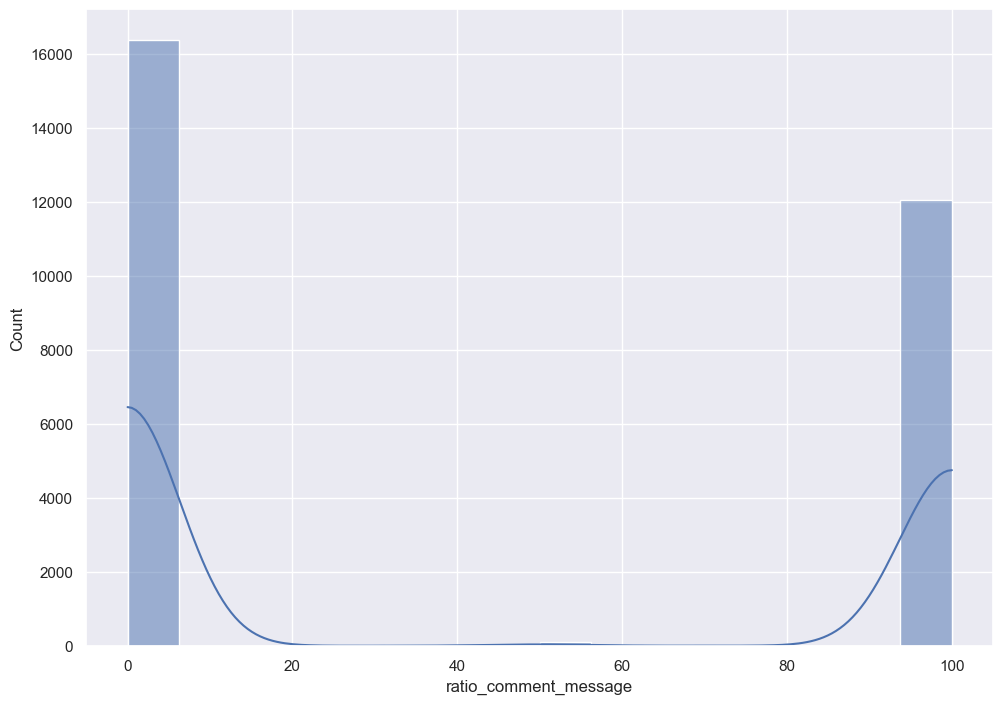

In [266]:
sns.histplot(df_customers, x='ratio_comment_message', kde=True)

## Payment methods

In [267]:
payments = data['order_payments']

In [268]:
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06
...,...,...,...,...,...,...,...,...
99433,9115830be804184b91f5c00f6f49f92d,da2124f134f5dfbce9d06f29bdb6c308,delivered,2017-10-04 19:57:37,2017-10-04 20:07:14,2017-10-05 16:52:52,2017-10-20 20:25:45,2017-11-07
99434,aa04ef5214580b06b10e2a378300db44,f01a6bfcc730456317e4081fe0c9940e,delivered,2017-01-27 00:30:03,2017-01-27 01:05:25,2017-01-30 11:40:16,2017-02-07 13:15:25,2017-03-17
99435,880675dff2150932f1601e1c07eadeeb,47cd45a6ac7b9fb16537df2ccffeb5ac,delivered,2017-02-23 09:05:12,2017-02-23 09:15:11,2017-03-01 10:22:52,2017-03-06 11:08:08,2017-03-22
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28


In [269]:
payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [270]:
matching_table.columns.to_list()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state',
 'review_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value',
 'seller_zip_code_prefix',
 'seller_city',
 'seller_state',
 'weight_qcut']

In [271]:
payments.merge(matching_table[['customer_unique_id', 'order_id']], on='order_id', how='inner')

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id
0,771ee386b001f06208a7419e4fc1bbd7,1,credit_card,1,81.16,9a3526eee723accd014ec683afe5bf20
1,3d7239c394a212faae122962df514ac7,1,credit_card,3,51.84,9db67268a3fee1d4b13faaeb90af07c0
2,0573b5e23cbd798006520e1d5b4c6714,1,boleto,1,51.95,511c345b0383af6ef25406c564e4d6b6
3,769214176682788a92801d8907fa1b40,1,credit_card,4,105.28,9b61cfcf9bc923fed1c1c8d38fab5a1c
4,5a1f6d22f7dfb061ef29216b9af687a1,1,credit_card,4,47.69,5986b5f70bf08b414d16a93ac5b1d76c
...,...,...,...,...,...,...
35775,4b186efcda6f283e9c4a71332f6d3ad0,1,credit_card,1,57.51,8247de12f35a00cf569c5b6a00a746ec
35776,c11717d999ffc510a6441df946f0a94d,1,credit_card,9,96.90,b388a93f3fdda4dc124231dfb9bd06d3
35777,387c2c33e495538e94878a500bf8e6d5,1,credit_card,1,87.58,d8ce0e44ece69672d6bb5dafabb21aa5
35778,0872d0faafe0cb56e6f2c594cca1522c,1,credit_card,2,127.92,4a57b2a3676de278e26a50b7e60214e6


In [272]:
payments_custo = payments.merge(matching_table[['customer_unique_id', 'order_id']], on='order_id', how='left')
payments_custo

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,NaN
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,NaN
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,NaN
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,NaN
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,NaN
...,...,...,...,...,...,...
108420,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31,NaN
108421,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80,53b30ca78efb2b7efcd3f9e461587eb2
108422,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77,NaN
108423,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54,NaN


In [273]:
payments.describe()

,payment_sequential,payment_installments,payment_value
count,103886.000000,103886.000000,103886.000000
mean,1.092679,2.853349,154.100380
std,0.706584,2.687051,217.494064
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,56.790000
50%,1.000000,1.000000,100.000000
75%,1.000000,4.000000,171.837500
max,29.000000,24.000000,13664.080000


In [274]:
payments_custo.describe()

,payment_sequential,payment_installments,payment_value
count,108425.000000,108425.000000,108425.000000
mean,1.097431,2.887175,160.009172
std,0.750395,2.720595,248.863183
min,1.000000,0.000000,0.000000
25%,1.000000,1.000000,57.770000
50%,1.000000,1.000000,102.300000
75%,1.000000,4.000000,176.200000
max,29.000000,24.000000,13664.080000


In [275]:
#payments = matching_table[['customer_unique_id', 'order_id', 'product_id', 'review_id']]\
#    .merge(products[['product_id', 'product_global_category']], on='product_id', how='inner')\
#    .merge(reviews[['review_id', 'review_score']])
#payments

In [276]:
payments

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


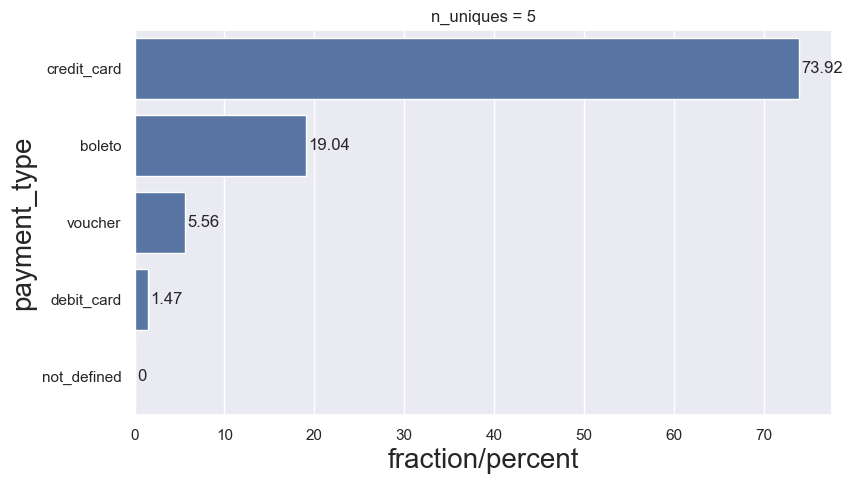

In [277]:
UVA.category(payments, ['payment_type'], 9, 5)

In [278]:
payments['payment_type'].isin(['credit_card']).sum()

76795

In [279]:
# count percent of na message per customer_unique_id
ratio_credit_card = payments_custo.groupby('customer_unique_id')['payment_type']\
                .apply(lambda x: x.isin(['credit_card']).sum()/len(x)*100).reset_index()
ratio_credit_card.rename({'payment_type':'ratio_credit_card'}, axis='columns', inplace=True)

ratio_credit_card.head()

,customer_unique_id,ratio_credit_card
0,0000f46a3911fa3c0805444483337064,100.0
1,0000f6ccb0745a6a4b88665a16c9f078,100.0
2,0005e1862207bf6ccc02e4228effd9a0,100.0
3,0006fdc98a402fceb4eb0ee528f6a8d4,100.0
4,000a5ad9c4601d2bbdd9ed765d5213b3,100.0


In [280]:
ratio_credit_card['ratio_credit_card'].value_counts(normalize=True).sort_index(ascending=False)

100.000000    0.731284
75.000000     0.000140
66.666667     0.000524
60.000000     0.000035
57.142857     0.000035
50.000000     0.023162
33.333333     0.002725
25.000000     0.000838
20.000000     0.000384
16.666667     0.000245
14.285714     0.000140
12.500000     0.000070
11.111111     0.000070
10.000000     0.000070
9.090909      0.000140
8.571429      0.000035
8.333333      0.000035
7.692308      0.000035
6.666667      0.000035
5.263158      0.000070
3.846154      0.000035
0.000000      0.239895
Name: ratio_credit_card, dtype: float64

<AxesSubplot:xlabel='ratio_credit_card', ylabel='Count'>

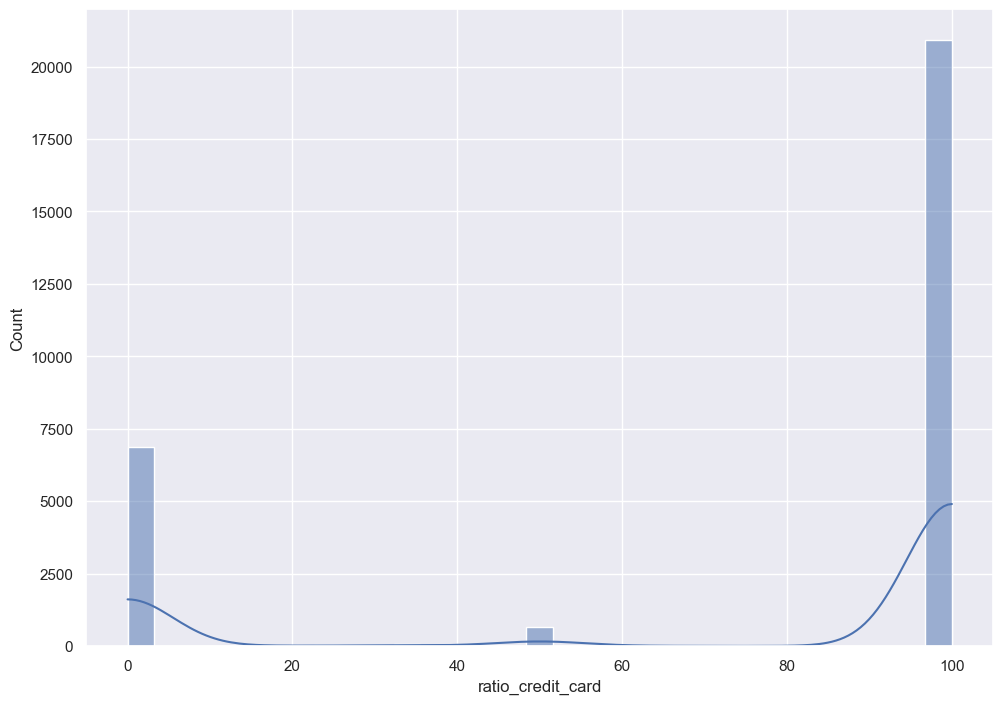

In [281]:
sns.histplot(ratio_credit_card, x='ratio_credit_card', kde=True)

In [282]:
# correlation with mean_pay_installments : removed

#df_customers = df_customers.merge(ratio_credit_card, on='customer_unique_id', how='left')
#df_customers.head()

In [283]:
#check + handling nulls
df_customers.isna().sum()

customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
dtype: int64

In [284]:
df_customers.head()

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message
0,7c396fd4830fd04220f754e42b4e5bff,15,0.00,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0,2,4,100.0
1,80bb27c7c16e8f973207a5086ab329e2,100,147.90,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,27.36,0,0,1,1,4,0.0
2,36edbb3fb164b1f16485364b6fb04c73,189,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.9,unknown,16.05,0,1,0,1,5,100.0
3,932afa1e708222e5821dac9cd5db4cae,154,59.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,15.17,1,0,0,1,5,0.0
4,39382392765b6dc74812866ee5ee92a7,267,0.00,0.00,0.0,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,furniture,16.05,1,0,0,1,4,0.0


In [285]:
#df_customers[df_customers['ratio_credit_card'].isna()]

In [286]:
### only 1 => remove

#df_customers.drop(df_customers[df_customers['ratio_credit_card'].isna()].index, inplace=True)

In [287]:
#df_customers['ratio_credit_card'].fillna(100, inplace=True)

print(df_customers.shape)
print(df_customers.isna().sum())

(28622, 30)
customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
dtype: int64


### median payment installments per user :

<AxesSubplot:xlabel='payment_installments', ylabel='Count'>

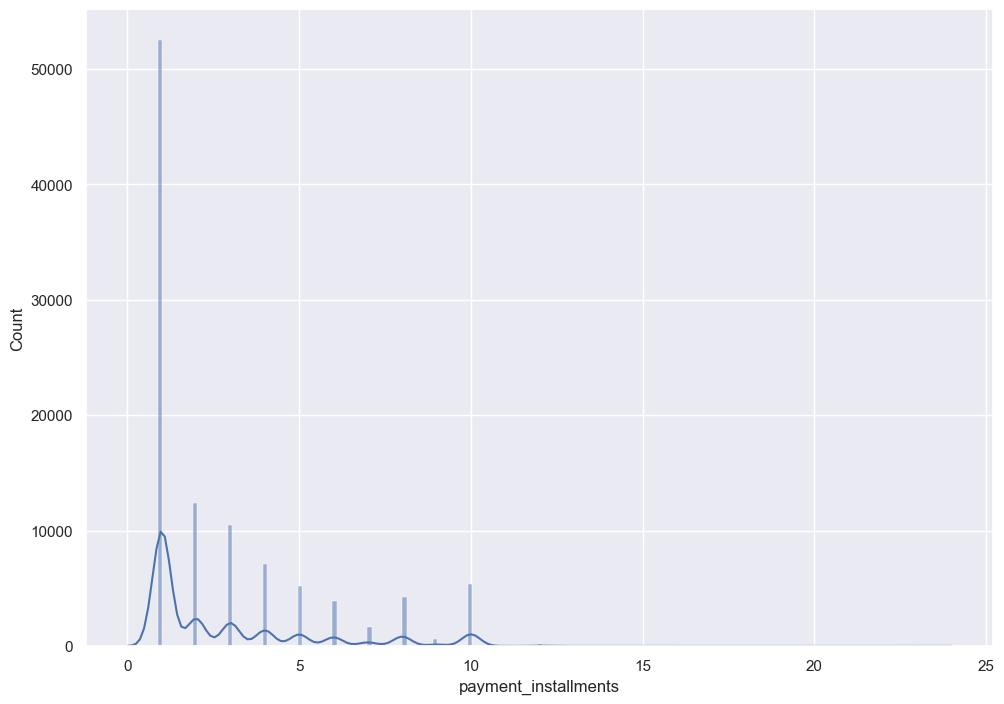

In [288]:
sns.histplot(payments, x='payment_installments', kde=True)

In [289]:
med_pay_install = payments_custo.groupby('customer_unique_id')['payment_installments']\
                .mean().reset_index()
med_pay_install.rename({'payment_installments':'mean_pay_installments'}, axis='columns', inplace=True)

print(med_pay_install.shape)
med_pay_install.head()

(28625, 2)


,customer_unique_id,mean_pay_installments
0,0000f46a3911fa3c0805444483337064,8.0
1,0000f6ccb0745a6a4b88665a16c9f078,4.0
2,0005e1862207bf6ccc02e4228effd9a0,3.0
3,0006fdc98a402fceb4eb0ee528f6a8d4,2.0
4,000a5ad9c4601d2bbdd9ed765d5213b3,3.0


In [290]:
payments_custo.loc[payments_custo['customer_unique_id'] == 'fffcf5a5ff07b0908bd4e2dbc735a684']

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id
46067,725cf8e9c24e679a8a5a32cb92c9ce1e,1,credit_card,10,2067.42,fffcf5a5ff07b0908bd4e2dbc735a684
46068,725cf8e9c24e679a8a5a32cb92c9ce1e,1,credit_card,10,2067.42,fffcf5a5ff07b0908bd4e2dbc735a684


In [291]:
med_pay_install.loc[med_pay_install['customer_unique_id'] == 'fffcf5a5ff07b0908bd4e2dbc735a684']

,customer_unique_id,mean_pay_installments
28622,fffcf5a5ff07b0908bd4e2dbc735a684,10.0


In [292]:
# insert into df_customers
df_customers = df_customers.merge(med_pay_install, on='customer_unique_id', how='left')
df_customers.head()

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message,mean_pay_installments
0,7c396fd4830fd04220f754e42b4e5bff,15,0.00,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0,2,4,100.0,1.0
1,80bb27c7c16e8f973207a5086ab329e2,100,147.90,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,27.36,0,0,1,1,4,0.0,6.0
2,36edbb3fb164b1f16485364b6fb04c73,189,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.9,unknown,16.05,0,1,0,1,5,100.0,1.0
3,932afa1e708222e5821dac9cd5db4cae,154,59.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,15.17,1,0,0,1,5,0.0,3.0
4,39382392765b6dc74812866ee5ee92a7,267,0.00,0.00,0.0,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,furniture,16.05,1,0,0,1,4,0.0,1.0


In [293]:
df_customers.isna().sum()

customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
mean_pay_installments    1
dtype: int64

In [294]:
#handle missing data
df_customers[df_customers['mean_pay_installments'].isna()]

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message,mean_pay_installments
8964,830d5b7aaa3b6f1e9ad63703bec97d23,397,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,134.97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,health_beauty,8.49,0,1,0,1,4,100.0,NaN


In [295]:
#df_customers['mean_pay_installments'].fillna(1, inplace=True)
df_customers.drop(df_customers[df_customers['mean_pay_installments'].isna()].index, inplace=True)

print(df_customers.shape)
print(df_customers.isna().sum())

(28621, 31)
customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
mean_pay_installments    0
dtype: int64


### payment sequential

In [296]:
payments.payment_sequential.value_counts()

1     99360
2      3039
3       581
4       278
5       170
6       118
7        82
8        54
9        43
10       34
11       29
12       21
13       13
14       10
15        8
18        6
19        6
16        6
17        6
21        4
20        4
22        3
26        2
24        2
23        2
25        2
29        1
28        1
27        1
Name: payment_sequential, dtype: int64

<AxesSubplot:xlabel='payment_sequential', ylabel='Count'>

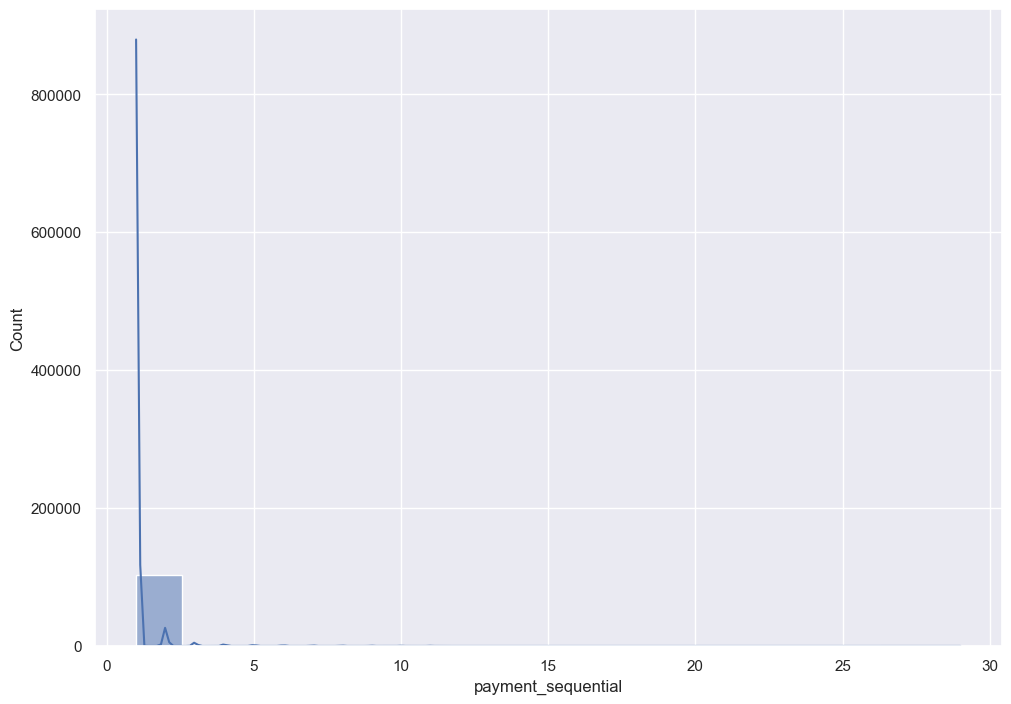

In [297]:
sns.histplot(payments, x='payment_sequential', kde=True)

In [298]:
med_pay_seq = payments_custo.groupby('customer_unique_id')['payment_sequential']\
                .mean().reset_index()
med_pay_seq.rename({'payment_sequential':'mean_pay_sequential'}, axis='columns', inplace=True)

print(med_pay_seq.shape)
med_pay_seq.head()

(28625, 2)


,customer_unique_id,mean_pay_sequential
0,0000f46a3911fa3c0805444483337064,1.0
1,0000f6ccb0745a6a4b88665a16c9f078,1.0
2,0005e1862207bf6ccc02e4228effd9a0,1.0
3,0006fdc98a402fceb4eb0ee528f6a8d4,1.0
4,000a5ad9c4601d2bbdd9ed765d5213b3,1.0


<AxesSubplot:xlabel='mean_pay_sequential', ylabel='Count'>

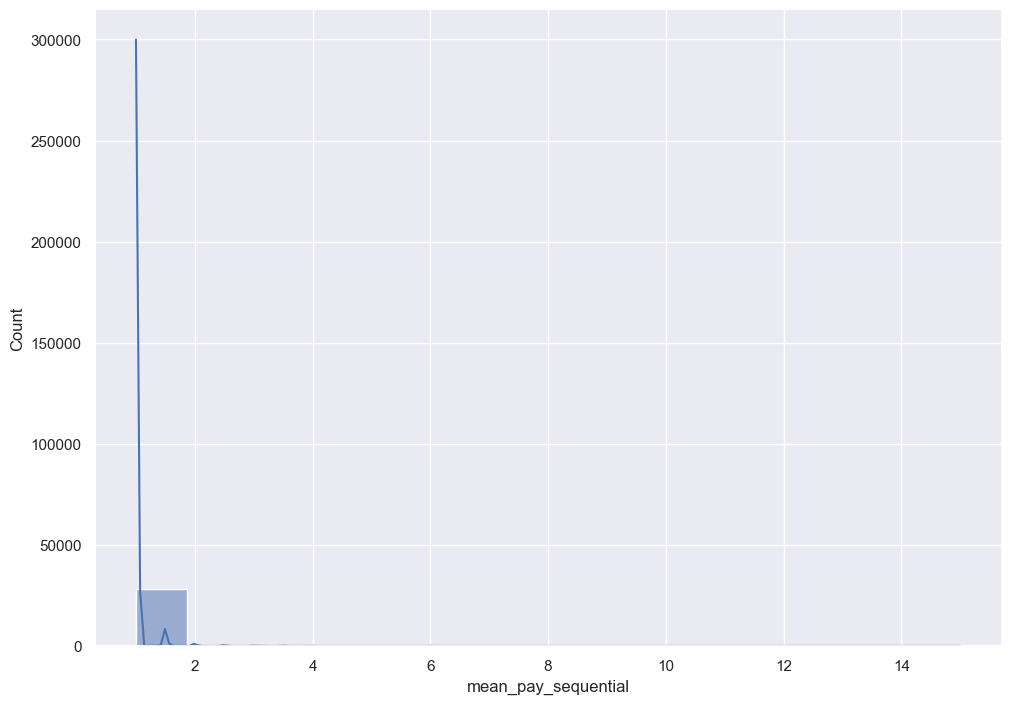

In [299]:
sns.histplot(med_pay_seq, x='mean_pay_sequential', kde=True)

In [300]:
med_pay_seq.sort_values(by='mean_pay_sequential', ascending=False)

,customer_unique_id,mean_pay_sequential
15580,8af7ac63b2efbcbd88e5b11505e8098a,15.00
9791,569aa12b73b5f7edeaa6f2a01603e381,13.50
17311,9a736b248f67d166d2fbb006bcb877c3,10.28
12549,6fbc7cdadbb522125f4b27ae9dee4060,10.00
4218,24f12460aad399ba18f4ed2c2fbab65d,10.00
...,...,...
9685,55a97ac4a03a60a3a30e1d7a9423b911,1.00
9684,55a44284e2c362a0199fb0df3ea9fb7d,1.00
9683,55a36fca00cebb9272a8e7d5b8325f59,1.00
9682,55a2c780cc65e883981402b88dbd44d7,1.00


In [301]:
payments_custo.loc[payments_custo['customer_unique_id'] == '8af7ac63b2efbcbd88e5b11505e8098a']

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id
5061,fa65dad1b0e818e3ccc5cb0e39231352,27,voucher,1,66.02,8af7ac63b2efbcbd88e5b11505e8098a
10365,fa65dad1b0e818e3ccc5cb0e39231352,4,voucher,1,29.16,8af7ac63b2efbcbd88e5b11505e8098a
14876,fa65dad1b0e818e3ccc5cb0e39231352,1,voucher,1,3.71,8af7ac63b2efbcbd88e5b11505e8098a
17957,fa65dad1b0e818e3ccc5cb0e39231352,9,voucher,1,1.08,8af7ac63b2efbcbd88e5b11505e8098a
20367,fa65dad1b0e818e3ccc5cb0e39231352,10,voucher,1,12.86,8af7ac63b2efbcbd88e5b11505e8098a
24000,fa65dad1b0e818e3ccc5cb0e39231352,2,voucher,1,8.51,8af7ac63b2efbcbd88e5b11505e8098a
25889,fa65dad1b0e818e3ccc5cb0e39231352,25,voucher,1,3.68,8af7ac63b2efbcbd88e5b11505e8098a
29510,fa65dad1b0e818e3ccc5cb0e39231352,5,voucher,1,0.66,8af7ac63b2efbcbd88e5b11505e8098a
30895,fa65dad1b0e818e3ccc5cb0e39231352,6,voucher,1,5.02,8af7ac63b2efbcbd88e5b11505e8098a
33914,fa65dad1b0e818e3ccc5cb0e39231352,11,voucher,1,4.03,8af7ac63b2efbcbd88e5b11505e8098a


In [302]:
# insert into df_customers
df_customers = df_customers.merge(med_pay_seq, on='customer_unique_id', how='left')
df_customers.head()

,customer_unique_id,recency,auto,baby,bed_bath_table,computers,computers_accessories,cool_stuff,fixed_telephony,furniture_decor,garden_tools,health_beauty,home_appliances_2,housewares,musical_instruments,office_furniture,small_appliances,sports_leisure,telephony,toys,watches_gifts,other_categories,main_category,freight_value,frequency_light,frequency_medium,frequency_heavy,sellers_count,mean_review_score,ratio_comment_message,mean_pay_installments,mean_pay_sequential
0,7c396fd4830fd04220f754e42b4e5bff,15,0.00,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.99,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,home,17.44,1,1,0,2,4,100.0,1.0,1.75
1,80bb27c7c16e8f973207a5086ab329e2,100,147.90,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,27.36,0,0,1,1,4,0.0,6.0,1.00
2,36edbb3fb164b1f16485364b6fb04c73,189,0.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.9,unknown,16.05,0,1,0,1,5,100.0,1.0,1.00
3,932afa1e708222e5821dac9cd5db4cae,154,59.99,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,auto,15.17,1,0,0,1,5,0.0,3.0,1.00
4,39382392765b6dc74812866ee5ee92a7,267,0.00,0.00,0.0,0.0,0.0,0.0,0.0,19.9,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,furniture,16.05,1,0,0,1,4,0.0,1.0,1.00


In [303]:
df_customers.isna().sum()

customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
mean_pay_installments    0
mean_pay_sequential      0
dtype: int64

In [304]:
#handle missing data
#df_customers[df_customers['mean_pay_sequential'].isna()]

In [305]:
#df_customers['mean_pay_sequential'].fillna(1, inplace=True)
df_customers.drop(df_customers[df_customers['mean_pay_sequential'].isna()].index, inplace=True)

print(df_customers.shape)
print(df_customers.isna().sum())

(28621, 32)
customer_unique_id       0
recency                  0
auto                     0
baby                     0
bed_bath_table           0
computers                0
computers_accessories    0
cool_stuff               0
fixed_telephony          0
furniture_decor          0
garden_tools             0
health_beauty            0
home_appliances_2        0
housewares               0
musical_instruments      0
office_furniture         0
small_appliances         0
sports_leisure           0
telephony                0
toys                     0
watches_gifts            0
other_categories         0
main_category            0
freight_value            0
frequency_light          0
frequency_medium         0
frequency_heavy          0
sellers_count            0
mean_review_score        0
ratio_comment_message    0
mean_pay_installments    0
mean_pay_sequential      0
dtype: int64


# Export Dataframe

In [306]:
contributive_features = ['recency', 'baby', 'computers', 'fixed_telephony', 'furniture_decor',
       'musical_instruments', 'sports_leisure', 'telephony', 'toys',
       'other_categories', 'freight_value', 'frequency_medium',
       'mean_review_score', 'ratio_comment_message']

# Sélection des features contributives dans le dataframe initial
df_reduced = df_customers[contributive_features]
df_reduced

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message
0,15,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,17.44,1,4,100.0
1,100,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,27.36,0,4,0.0
2,189,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,49.9,16.05,1,5,100.0
3,154,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,15.17,0,5,0.0
4,267,0.00,0.0,0.0,19.9,0.0,0.0,0.0,0.00,0.0,16.05,0,4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28616,13,0.00,0.0,0.0,0.0,0.0,0.0,0.0,69.01,0.0,37.78,1,5,0.0
28617,263,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,19.43,1,1,0.0
28618,236,0.00,0.0,0.0,139.9,0.0,0.0,0.0,0.00,0.0,16.09,0,1,0.0
28619,222,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,13.08,1,5,0.0


## Overall view

In [307]:
# drop category col already encoded otherwise through pivot+ low variance filter
df_reduced.head()

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message
0,15,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.44,1,4,100.0
1,100,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.36,0,4,0.0
2,189,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49.9,16.05,1,5,100.0
3,154,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.17,0,5,0.0
4,267,0.00,0.0,0.0,19.9,0.0,0.0,0.0,0.0,0.0,16.05,0,4,0.0


In [308]:
df_reduced.shape

(28621, 14)

In [309]:
df_reduced.isna().sum().sum()

0

In [310]:
df_reduced.duplicated().sum()

517

In [311]:
df_reduced.columns.tolist()

['recency',
 'baby',
 'computers',
 'fixed_telephony',
 'furniture_decor',
 'musical_instruments',
 'sports_leisure',
 'telephony',
 'toys',
 'other_categories',
 'freight_value',
 'frequency_medium',
 'mean_review_score',
 'ratio_comment_message']

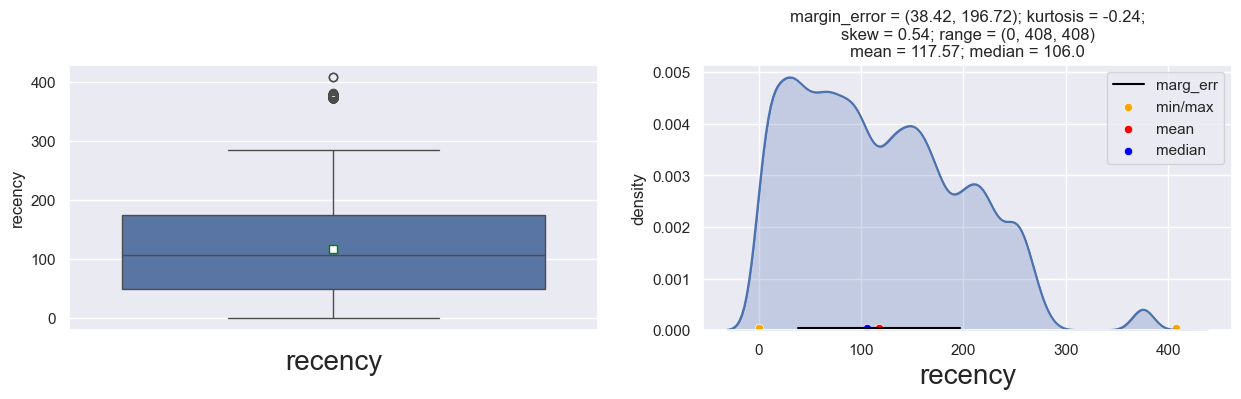

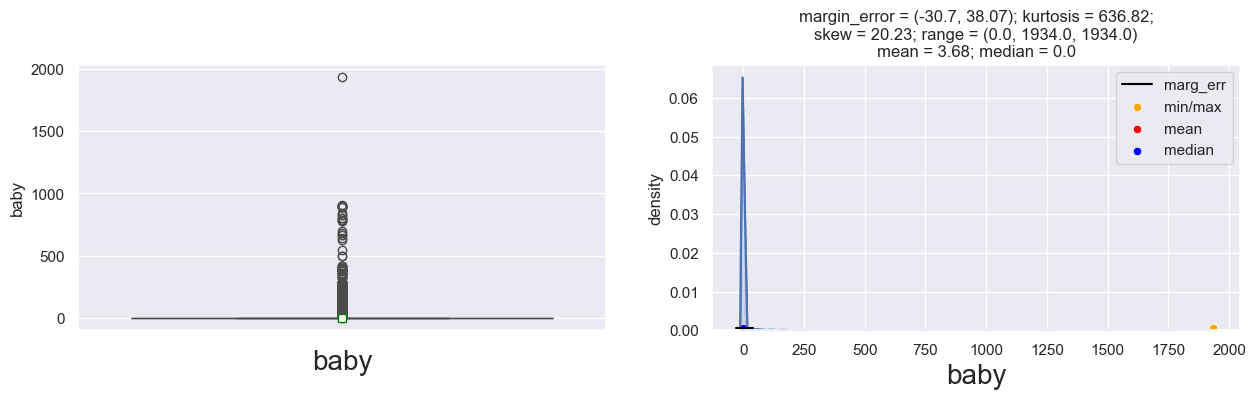

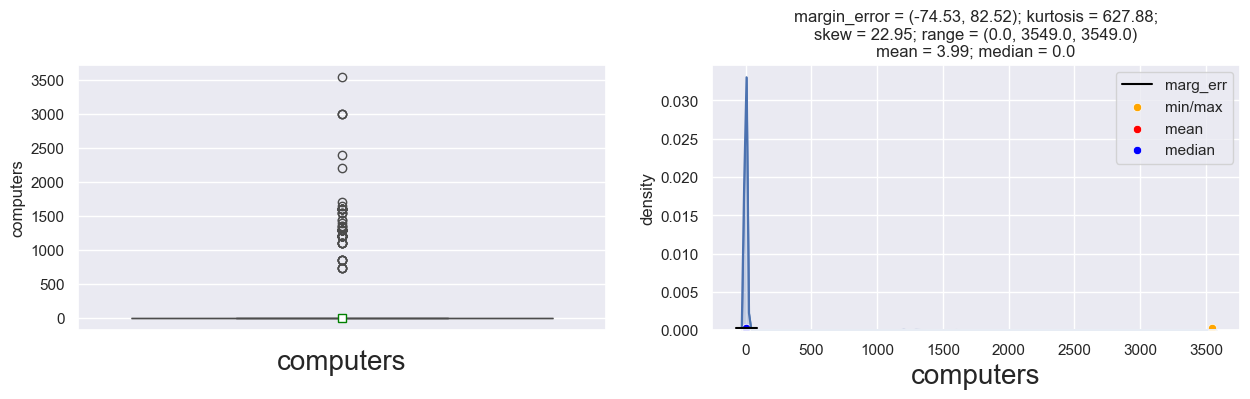

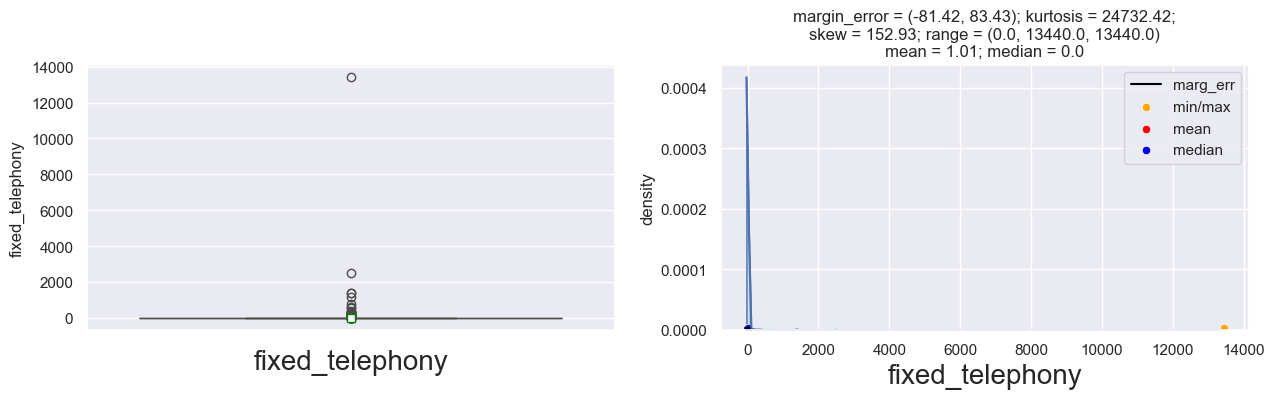

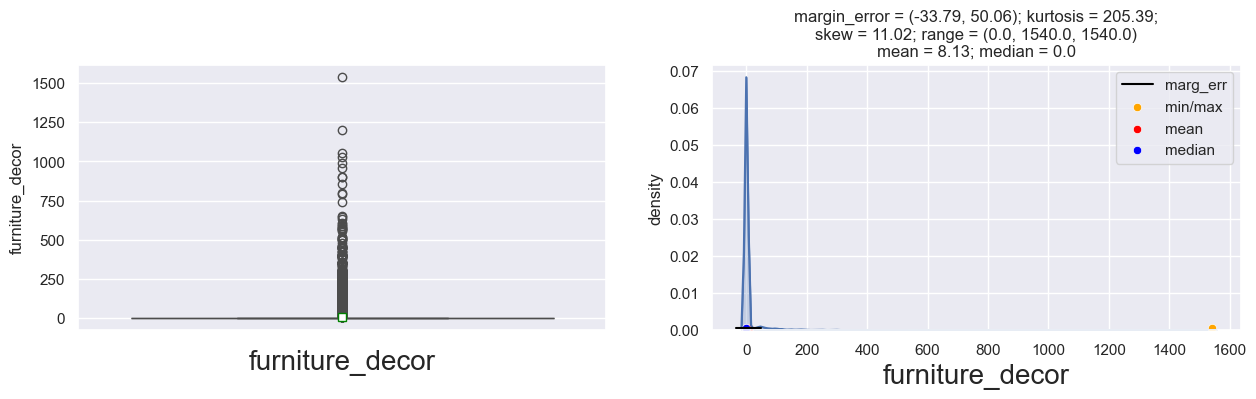

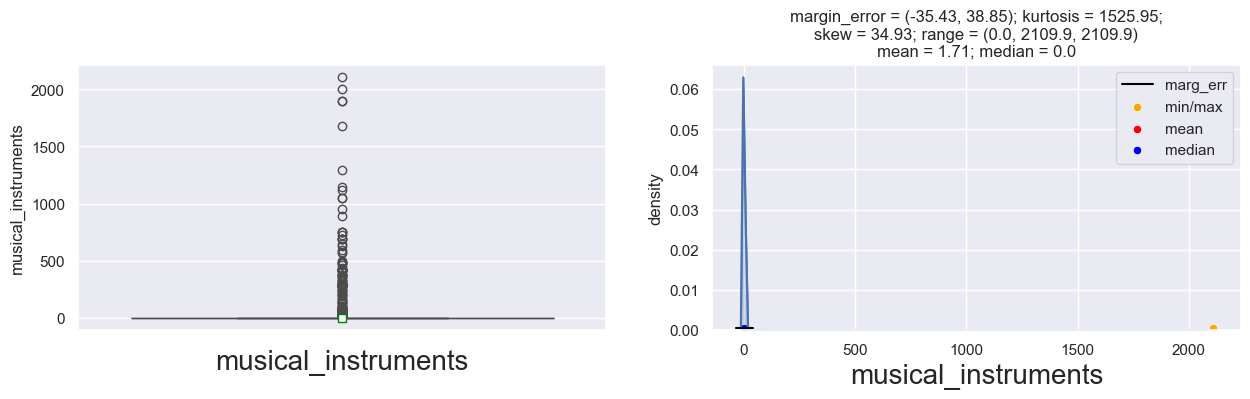

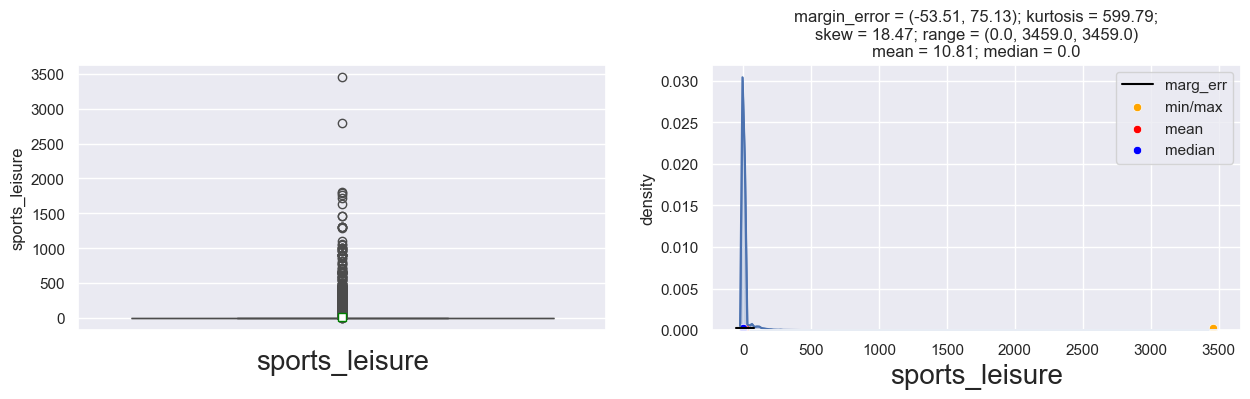

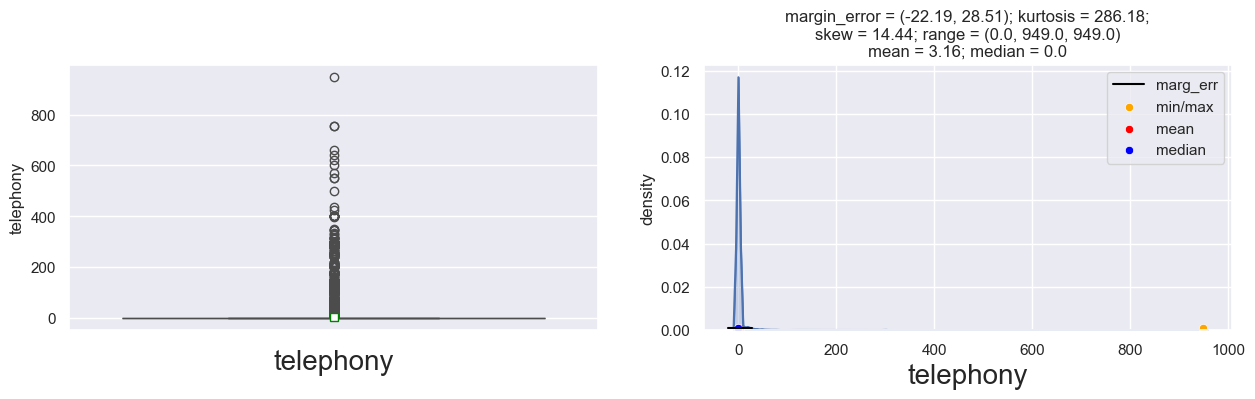

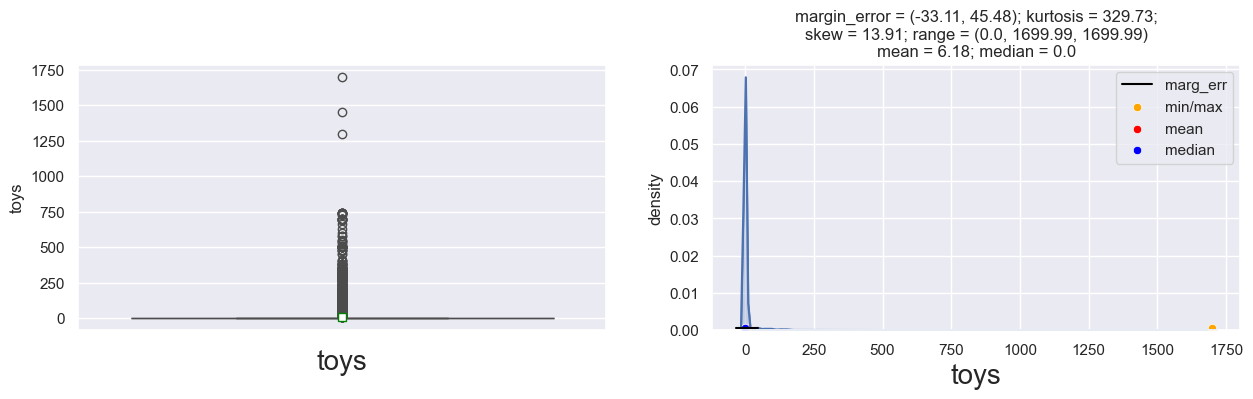

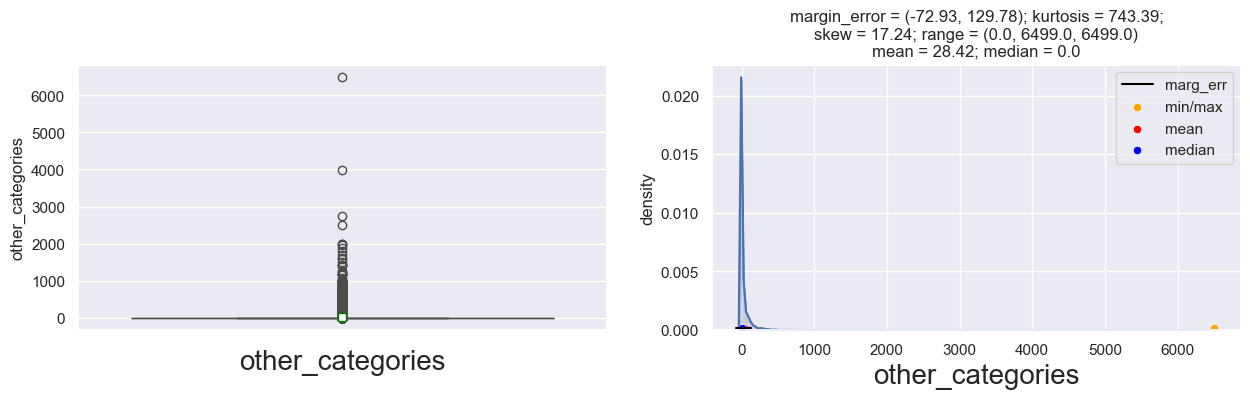

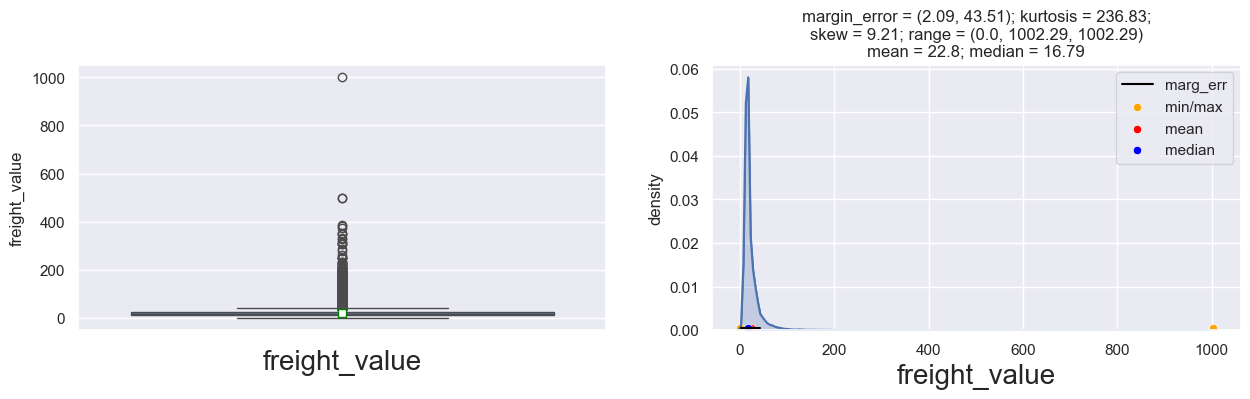

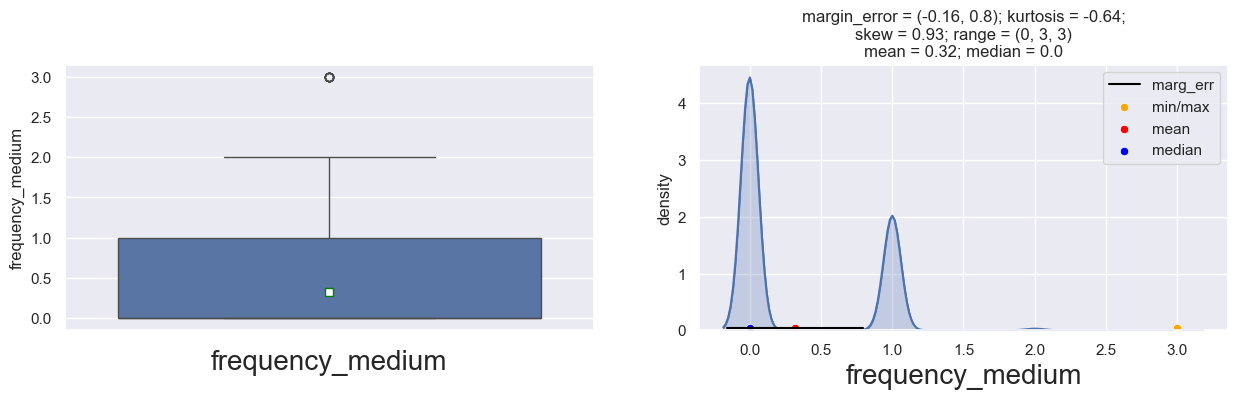

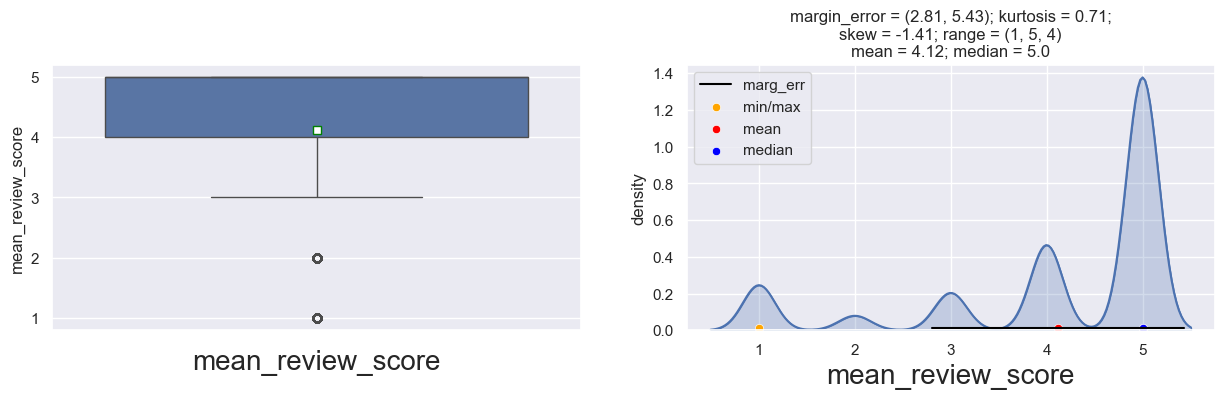

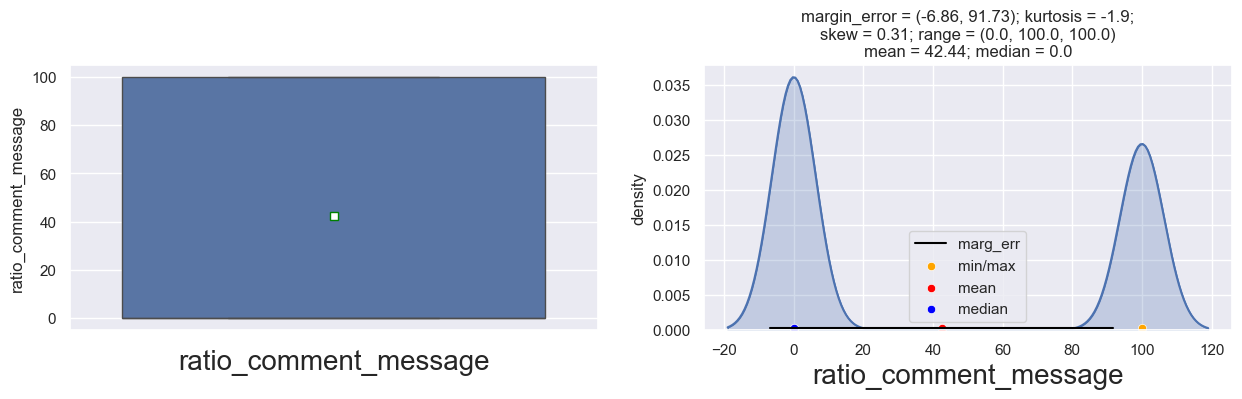

In [312]:
UVA.num_plus(df_reduced, df_reduced.columns)

## reindex + export

In [313]:
df_reduced

,recency,baby,computers,fixed_telephony,furniture_decor,musical_instruments,sports_leisure,telephony,toys,other_categories,freight_value,frequency_medium,mean_review_score,ratio_comment_message
0,15,35.39,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,17.44,1,4,100.0
1,100,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,27.36,0,4,0.0
2,189,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,49.9,16.05,1,5,100.0
3,154,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,15.17,0,5,0.0
4,267,0.00,0.0,0.0,19.9,0.0,0.0,0.0,0.00,0.0,16.05,0,4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28616,13,0.00,0.0,0.0,0.0,0.0,0.0,0.0,69.01,0.0,37.78,1,5,0.0
28617,263,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,19.43,1,1,0.0
28618,236,0.00,0.0,0.0,139.9,0.0,0.0,0.0,0.00,0.0,16.09,0,1,0.0
28619,222,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,13.08,1,5,0.0


In [314]:
path = './data/'

df_reduced.to_csv(path + f'{csv_export_name}.csv', index=False)
print(f'export {csv_export_name} finished !')

export customers_2016-09-04_2017-10-17 finished !


In [315]:
pwd

'\\\\wsl.localhost\\Ubuntu\\home\\dgaillot\\code\\openclassrooms\\openclassrooms\\projets\\projet_5'

In [316]:
#ls -lh ./data

In [317]:
df_reduced.shape

(28621, 14)

In [318]:
## method building : error check/catch : only process if elements are numerical values

In [319]:
## todo : clustering sur RFM : kmeans / dbscan